<a href="https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print('Comment notation:')
print('#: description of what is being done')
print('##: question')
print('###: problem')
print('####: task')

print("colab link: https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb")

Comment notation:
#: description of what is being done
##: question
###: problem
####: task
colab link: https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb


In [2]:
# import tools

# standard library
import os
import types
import sys
import inspect
import yaml
import time
import ipyparallel as ipp

# scientific stack
import numpy as np
import jax.numpy as jnp
import scipy
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.integrate import simpson
from scipy.ndimage import gaussian_filter1d

# cosmology
import astropy
import astropy.units as units
from astropy.cosmology import LambdaCDM, w0waCDM
import pyccl as ccl
import camb
from camb import model, initialpower
import classy
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX as CPJ

# plotting
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# inference / sampling
import cobaya
from cobaya.run import run as cobaya_run
from cobaya.likelihood import Likelihood
from cobaya.model import get_model
#from cobaya_utilities import tools -- this wont import, but I don't use it at the momment anyway
import getdist
import getdist.plots as plots
from getdist import plots, MCSamples
from getdist.mcsamples import MCSamples
from getdist.mcsamples import loadMCSamples

# notebook only (remove if this becomes a .py module)
%matplotlib inline

In [3]:
# import custom helper functions and classes

# functions
from functions_and_classes import calculate_and_plot_Cls
from functions_and_classes import build_tracers_from_data
from functions_and_classes import build_tracer_dict
from functions_and_classes import build_noise_dict
from functions_and_classes import build_spectra_dict
from functions_and_classes import create_simplified_desired_pairs
from functions_and_classes import build_covariance_from_data
from functions_and_classes import plot_covariance_matrix
from functions_and_classes import plot_correlation_matrix
from functions_and_classes import plot_spectra_from_dict
from functions_and_classes import make_Pk2D
from functions_and_classes import predict_linear_Pk
from functions_and_classes import predict_boost_Pk
from functions_and_classes import instrument_Pk2D
from functions_and_classes import plot_cobaya_mcmc_results

# classes
from functions_and_classes import ForecastMap
from functions_and_classes import CovarianceMatrix
from functions_and_classes import SO_x_DESI_Likelihood_A_s_version
from functions_and_classes import SO_x_DESI_Likelihood_w_emulator
from functions_and_classes import SO_x_DESI_Likelihood_sigma8_version
from functions_and_classes import SO_x_DESI_Likelihood_w_emulator_and_JAX
from functions_and_classes import Pk2DTimer

LOADING FILE: /global/u2/l/lialubit/DESIxSO/functions_and_classes.py


In [4]:
#import pre-trained P(k) emulators stored in emulator file

lin_emu = CPJ(probe='mpk_lin')
boost_emu = CPJ(probe='mpk_boost')

print('linear P(k) emulator parameters: ', lin_emu.parameters)
print('boost P(k) emulator parameters: ', boost_emu.parameters)

linear P(k) emulator parameters:  ['omega_b', 'omega_cdm', 'h', 'n_s', 'ln10^{10}A_s', 'z']
boost P(k) emulator parameters:  ['omega_b', 'omega_cdm', 'h', 'n_s', 'ln10^{10}A_s', 'cmin', 'eta_0', 'z']


## Data and Noise

In [5]:
# data

# DESI-HSC
HSC_dist_0_3 = np.load("data/distributions_0.3_3_vF.npz")
print(f"Keys in distributions_0.3_3_vF.npz: {HSC_dist_0_3.files}")

HSC_dist_1_5 = np.load("data/distributions_1_5_vF.npz")
print(f"Keys in distributions_1_5_vF.npz: {HSC_dist_1_5.files}")

HSC_dist_0_3_a = np.load("data/distributions_0.3_3_vF.npz")['1/nz_mean']
HSC_dist_0_3_b = np.load("data/distributions_0.3_3_vF.npz")['2/nz_mean']
HSC_dist_0_3_c = np.load("data/distributions_0.3_3_vF.npz")['3/nz_mean']
HSC_dist_0_3_d = np.load("data/distributions_0.3_3_vF.npz")['4/nz_mean']
HSC_dist_0_3_z = np.load("data/distributions_0.3_3_vF.npz")['z']
HSC_dist_0_3 = np.column_stack((HSC_dist_0_3_z, HSC_dist_0_3_a, HSC_dist_0_3_b, HSC_dist_0_3_c, HSC_dist_0_3_d)) # make into 2D array for easy processing

HSC_dist_1_5_a = np.load("data/distributions_1_5_vF.npz")['1/nz_mean']
HSC_dist_1_5_b = np.load("data/distributions_1_5_vF.npz")['2/nz_mean']
HSC_dist_1_5_c = np.load("data/distributions_1_5_vF.npz")['3/nz_mean']
HSC_dist_1_5_d = np.load("data/distributions_1_5_vF.npz")['4/nz_mean']
HSC_dist_1_5_z = np.load("data/distributions_1_5_vF.npz")['z']
HSC_dist_1_5 = np.column_stack((HSC_dist_1_5_z, HSC_dist_1_5_a, HSC_dist_1_5_b, HSC_dist_1_5_c, HSC_dist_1_5_d)) # make into 2D array for easy processing

# DESI Lens Data

DESI_lens_data = np.loadtxt("data/des_nz_gamma.txt")

DESI_lens_data = DESI_lens_data[7:]  # removes the first 7 values (headers)
DESI_lens_data = DESI_lens_data.reshape(-1, 6) #shape into array with columns z, nz0 -- nz4

# Split into separate arrays
DESI_lens_z    = DESI_lens_data[:, 0]
DESI_lens_nz_a = DESI_lens_data[:, 1]
DESI_lens_nz_b = DESI_lens_data[:, 2]
DESI_lens_nz_c = DESI_lens_data[:, 3]
DESI_lens_nz_d = DESI_lens_data[:, 4]
DESI_lens_nz_e = DESI_lens_data[:, 5]

DESI_lens_data = np.column_stack((DESI_lens_z, DESI_lens_nz_a, DESI_lens_nz_b, DESI_lens_nz_c, DESI_lens_nz_d))

Keys in distributions_0.3_3_vF.npz: ['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_upper', '4/nz_median_mu', '4/nz_mean_mu', '4/nz_lower_mu', '4/nz_upper_mu']
Keys in distributions_1_5_vF.npz: ['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_up

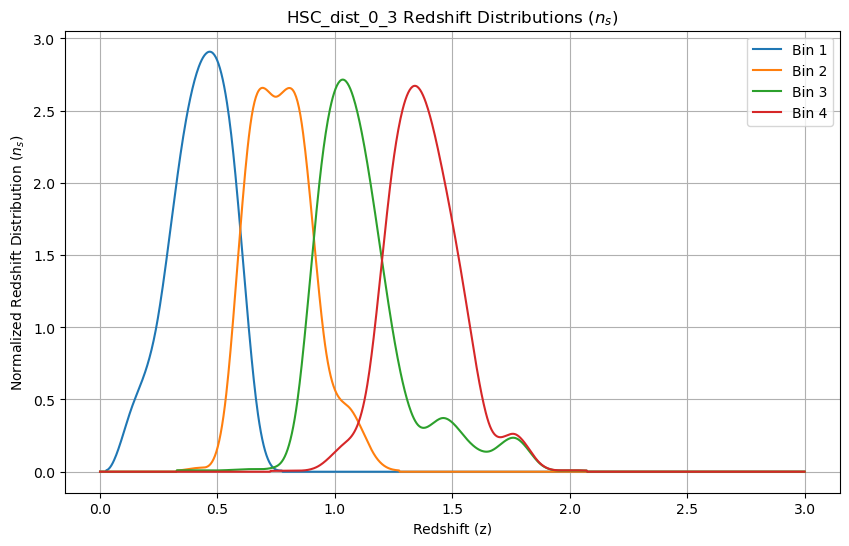

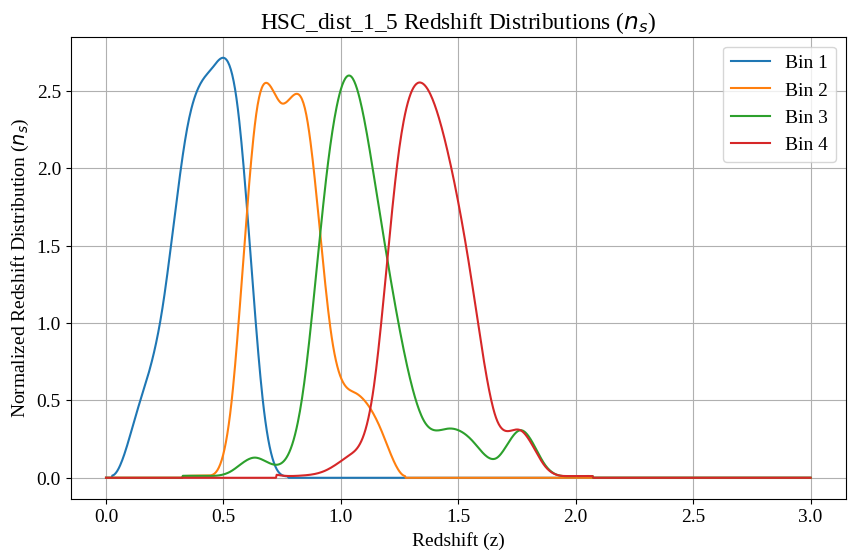

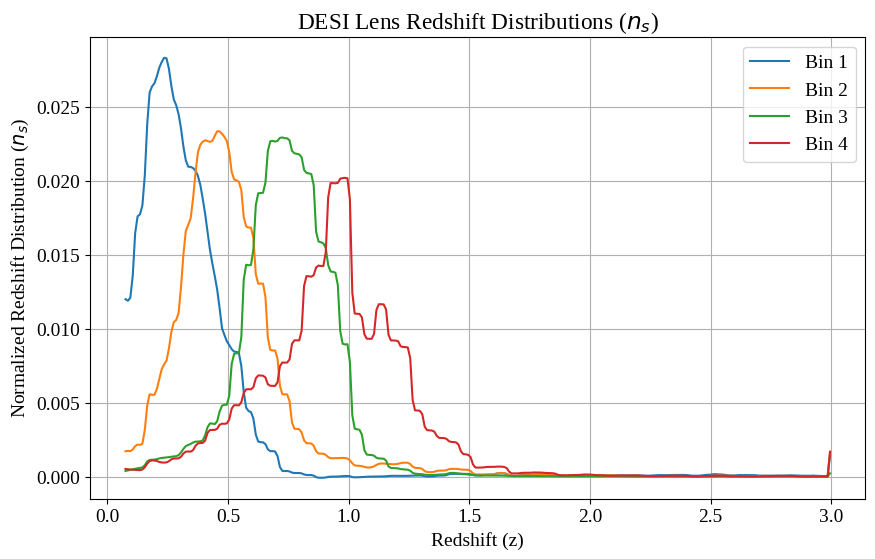

In [6]:
# graph HSC source distributions

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_a, label='Bin 1')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_b, label='Bin 2')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_c, label='Bin 3')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_0_3 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_a, label='Bin 1')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_b, label='Bin 2')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_c, label='Bin 3')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_1_5 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(DESI_lens_z, DESI_lens_nz_a, label='Bin 1')
plt.plot(DESI_lens_z, DESI_lens_nz_b, label='Bin 2')
plt.plot(DESI_lens_z, DESI_lens_nz_c, label='Bin 3')
plt.plot(DESI_lens_z, DESI_lens_nz_d, label='Bin 4')
#plt.plot(DESI_lens_z, DESI_lens_nz_e, label='Bin 5')
#### nz_5 has values all of order e7 or above,
#### while the others have values of order e-5 or below
#### what's going on here?
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('DESI Lens Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

In [18]:
# build DESI, SO noise, and magnification
# shot noise ref: https://arxiv.org/pdf/2407.04607
# shape noise ref: slack from Simone, can't find the Github itself
# SO noise ref:
# magnification ref: https://arxiv.org/pdf/2503.24385

sigma = 0.26
DESI_n_bar_deg2 = np.array([81.9, 148.1, 162.4, 148.3]) # Galaxies per square degree

# Convert n_bar from per deg^2 to per steradian
# 1 steradian = (180/pi)^2 square degrees
DESI_n_bar_steradian = DESI_n_bar_deg2 * (180.0 / np.pi)**2

DESI_shot_noise = np.zeros_like(DESI_n_bar_steradian)
DESI_shape_noise = np.zeros_like(DESI_n_bar_steradian)
for i in range(len(DESI_shot_noise)):
    DESI_shot_noise[i] = 1 / DESI_n_bar_steradian[i]
    DESI_shape_noise[i] = sigma ** 2 / DESI_n_bar_steradian[i]

# CMB noise arises from idk a bunch of stuff
# we have an SO noise curve, but it does not have precisely the same ells as our C_l
# we must interpolate the N_kk to produce a useful noise curve
SO_noise_data = np.genfromtxt("data/nlkk_v3_1_0deproj0_SENS2_fsky0p4_it_lT30-3000_lP30-5000.dat")
S_noise_ells = SO_noise_data[:, 0]
N_kk = SO_noise_data[:, 7]
ells_for_noise_interp = np.arange(2, 5000 + 2) # Assuming n_ell = 5000 for new analysis
low_ells_for_noise_interp = np.arange(2, 1500 + 2)

# Use fill_value=(N_kk[0], N_kk[-1]) to cap the noise at the boundaries
interpolated_N_kk_func = interp1d(S_noise_ells, N_kk, bounds_error=False, fill_value=(N_kk[0], N_kk[-1]))
SO_CMB_noise = interpolated_N_kk_func(ells_for_noise_interp)
low_l_SO_CMB_noise = interpolated_N_kk_func(low_ells_for_noise_interp)
# Handle potential negative noise if for some reason the source data contains them, set to a small positive number
SO_CMB_noise[SO_CMB_noise < 0] = 1e-30 # Or whatever appropriate small value
low_l_SO_CMB_noise[low_l_SO_CMB_noise < 0] = 1e-30

# save
# make sure folder exists
os.makedirs("data", exist_ok=True)
np.save("data/SO_CMB_noise.npy", SO_CMB_noise)
print("Saved SO_CMB_noise to data/SO_CMB_noise.npy")
np.save("data/low_l_SO_CMB_noise.npy", low_l_SO_CMB_noise)
print("Saved shortened SO_CMB_noise to data/SO_CMB_noise.npy")

Saved SO_CMB_noise to data/SO_CMB_noise.npy
Saved shortened SO_CMB_noise to data/SO_CMB_noise.npy


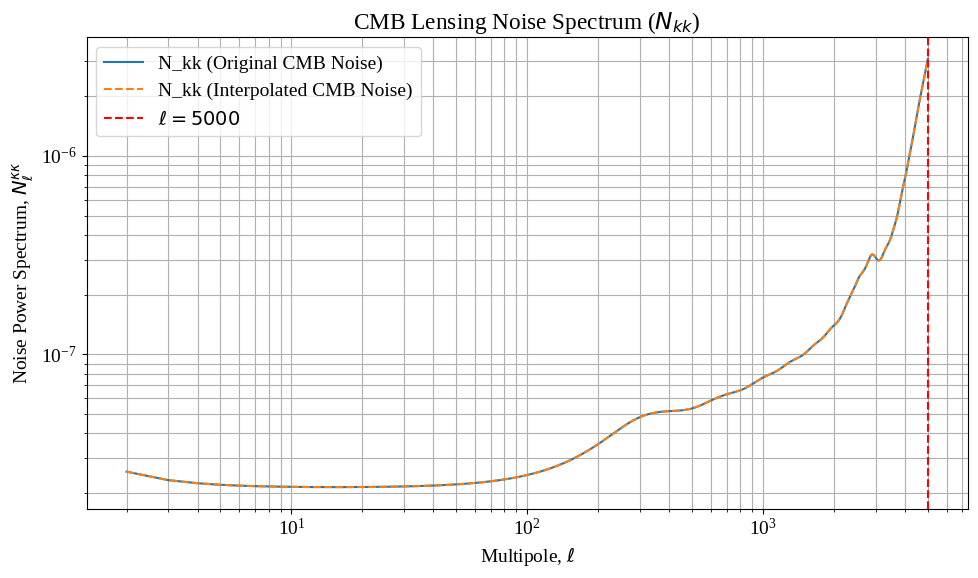

In [19]:
# plot N_kk to see what it looks like

plt.figure(figsize=(10, 6))
plt.loglog(S_noise_ells, N_kk, label='N_kk (Original CMB Noise)')
plt.loglog(ells_for_noise_interp, SO_CMB_noise, label='N_kk (Interpolated CMB Noise)', linestyle='--')
plt.xlabel('Multipole, $\ell$')
plt.ylabel('Noise Power Spectrum, $N_{\ell}^{\kappa\kappa}$')
plt.title('CMB Lensing Noise Spectrum ($N_{kk}$)')
plt.axvline(x=5000, color='red', linestyle='--', label='$\ell = 5000$') # Added vertical line
plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()

In [20]:
# make and save noise and data files for just the first bin

# make sure folder exists
os.makedirs("data", exist_ok=True)

# data
DESI_lens_data_bin1 = DESI_lens_data[:, :2]  # z + first lens bin
HSC_dist_0_3_bin1 = HSC_dist_0_3[:, :2]       # z + first source bin

# noise
DESI_shot_noise_bin1 = np.array([DESI_shot_noise[0]])
DESI_shape_noise_bin1 = np.array([DESI_shape_noise[0]])
#SO_CMB_noise was already saved

# save
np.save("data/DESI_lens_data_bin1.npy", DESI_lens_data_bin1)
np.save("data/HSC_dist_0_3_bin1.npy", HSC_dist_0_3_bin1)
np.save("data/DESI_shot_noise_bin1.npy", DESI_shot_noise_bin1)
np.save("data/DESI_shape_noise_bin1.npy", DESI_shape_noise_bin1)
#SO_CMB_noise was already saved
    
# check
print("DESI_lens_data_bin1 shape:", DESI_lens_data_bin1.shape)
print("HSC_dist_0_3_bin1 shape:", HSC_dist_0_3_bin1.shape)
print("DESI_shot_noise_bin1:", DESI_shot_noise_bin1)
print("DESI_shape_noise_bin1:", DESI_shape_noise_bin1)
print("SO_CMB_noise:", SO_CMB_noise)

DESI_lens_data_bin1 shape: (293, 2)
HSC_dist_0_3_bin1 shape: (1000, 2)
DESI_shot_noise_bin1: [3.71938241e-06]
DESI_shape_noise_bin1: [2.51430251e-07]
SO_CMB_noise: [2.566829e-08 2.327497e-08 2.244052e-08 ... 3.084815e-06 3.088479e-06
 3.088479e-06]


In [21]:
# 1. Save Full DESI Lens Data (all 4 bins: columns z, nz_a, nz_b, nz_c, nz_d)
# Note: DESI_lens_data was already column-stacked in Cell 4
np.save("data/DESI_lens_data.npy", DESI_lens_data)

# 2. Save Full HSC Source Data (all 4 bins for both redshift ranges)
np.save("data/HSC_dist_0_3.npy", HSC_dist_0_3)
np.save("data/HSC_dist_1_5.npy", HSC_dist_1_5)

# 3. Save Full DESI Shot Noise and Shape Noise (Arrays for all 4 bins)
# These were calculated for all bins using DESI_n_bar_steradian in Cell 8
np.save("data/DESI_shot_noise.npy", DESI_shot_noise)
np.save("data/DESI_shape_noise.npy", DESI_shape_noise)

# Verification Printouts
print("Full datasets saved successfully!")
print("DESI Lens Data shape: ", DESI_lens_data.shape)
print("HSC 0.3-3 Dist shape: ", HSC_dist_0_3.shape)
print("DESI Shot Noise array:", DESI_shot_noise)
print("DESI Shape Noise array:", DESI_shape_noise)

Full datasets saved successfully!
DESI Lens Data shape:  (293, 5)
HSC 0.3-3 Dist shape:  (1000, 5)
DESI Shot Noise array: [3.71938241e-06 2.05683606e-06 1.87572303e-06 2.05406217e-06]
DESI Shape Noise array: [2.51430251e-07 1.39042117e-07 1.26798877e-07 1.38854603e-07]


## CCL and CosmoPower

In [8]:
# CCL and CosmoPower
print('CCL cosmology parameters:')
print('Omega_c: the density fraction at z=0 of CDM.')
print('Omega_b: the density fraction at z=0 of baryons.')
print('h: the Hubble constant in units of 100 k⁢m/s/M⁢p⁢c.')
print('Omega_k: the curvature density fraction at 𝑧 =0.')
print('Omega_g: the density of radiation (not including massless neutrinos.')
print('w0: first order term of the dark energy equation of state.')
print('wa: second order term of the dark energy equation of state.')

CCL cosmology parameters:
Omega_c: the density fraction at z=0 of CDM.
Omega_b: the density fraction at z=0 of baryons.
h: the Hubble constant in units of 100 k⁢m/s/M⁢p⁢c.
Omega_k: the curvature density fraction at 𝑧 =0.
Omega_g: the density of radiation (not including massless neutrinos.
w0: first order term of the dark energy equation of state.
wa: second order term of the dark energy equation of state.


In [9]:
# CCL cosmolgoies

# сosmology -- standard CCL + DESI waw0
h = 0.6674
w0 = -0.752
wa = -0.86
Om0 = 0.3191
Omega_c = 0.27
Omega_b = 0.045
sigma8 = 0.8
A_s = 2.105e-9
n_s = 0.96
w0wa_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s,
                               n_s=n_s, w0=w0, wa=wa, transfer_function='boltzmann_camb')

# сosmology -- standard CCL + DESI curved h and Omega_k
h = 0.6850
Om0 = 0.3191
Omega_c = 0.27
Omega_b = 0.045
sigma8 = 0.8
A_s = 2.105e-9
n_s = 0.96
Omega_k = 2.3e-3
curved_LCDM_cosmology = ccl.Cosmology(Omega_k = Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s,
                               n_s=n_s, transfer_function='boltzmann_camb')

# cosmology -- standard CCL + flat LCDM
z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
n_s=0.96
A_s = 2.105e-9
Omega_c = 0.27
flat_LCDM_cosmology = ccl.Cosmology(Omega_k = Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s = A_s,
                               n_s=n_s, transfer_function='boltzmann_camb')

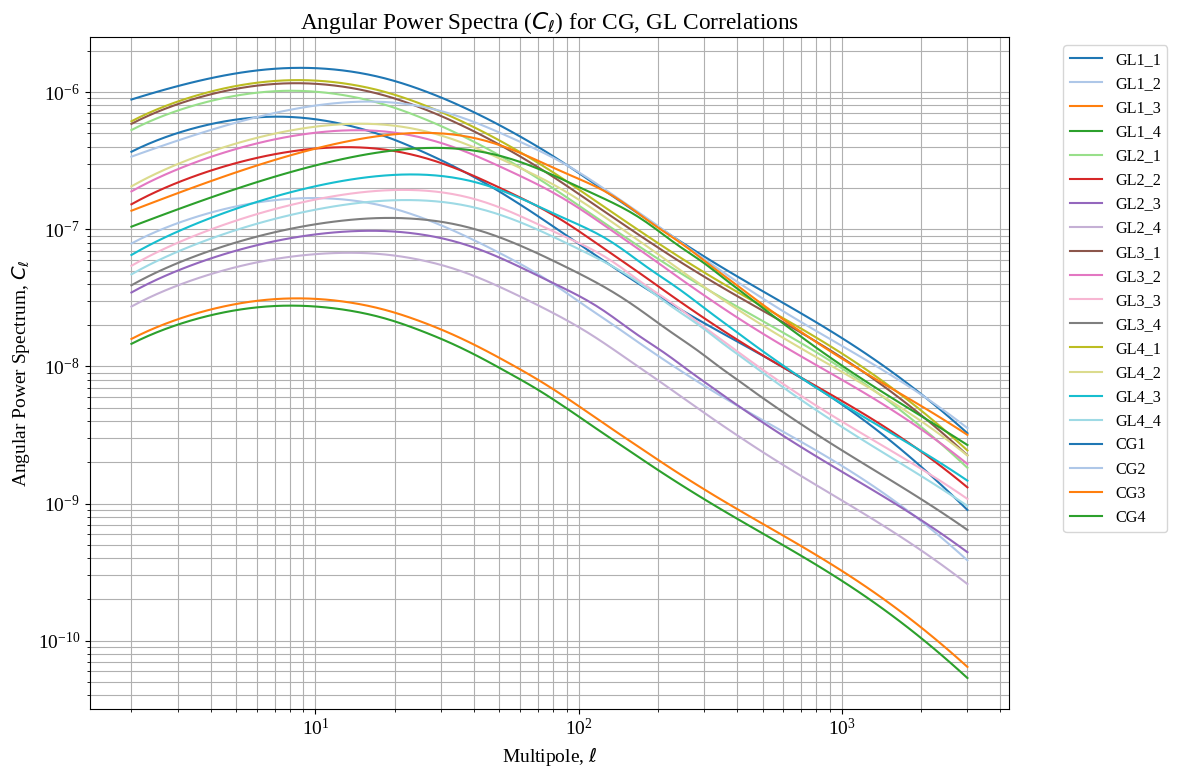

In [10]:
# plot lensing ratio angular power spectra w/o emulator

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CG', 'GL'])

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


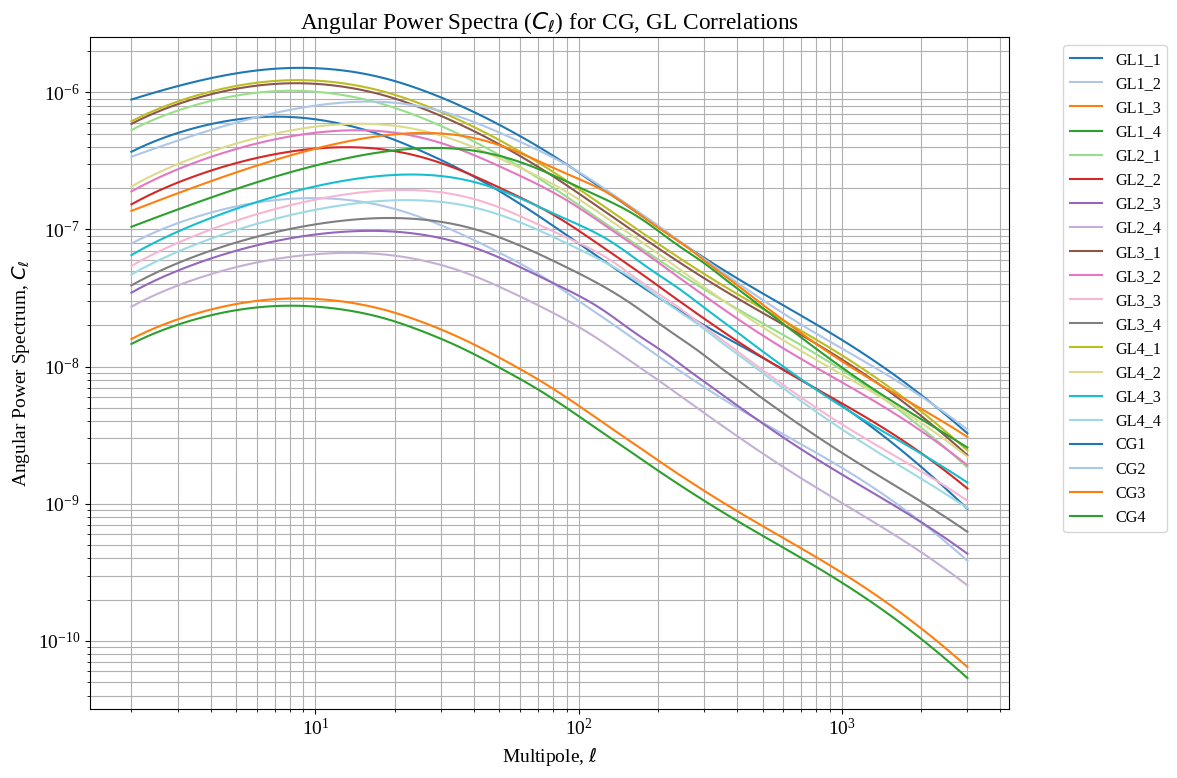

In [11]:
# plot angular power spectra w/ emulator

a_grid = np.linspace(1/(1+5), 1.0, 20)
z_grid = (1.0 / a_grid) - 1.0

Pk2D_full = make_Pk2D(
    flat_LCDM_cosmology, # Use the same cosmology to ensure parameter consistency
    linear_emulator=lin_emu,
    boost_emulator=boost_emu,
    z_arr=z_grid,
    cmin=3.13,
    eta_0=0.60
)

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CG', 'GL'],
    Pk2D_object = Pk2D_full
)

## Convariance Matrices

The covariance matrix is rather complicated because we have many different types of data for which we need to consider the covariances. We'll set up the data vector:

$$\mathbf{D} = [C_\ell^{\phi\phi}, C_\ell^{gg}, C_\ell^{\gamma\gamma}, C_\ell^{g\gamma}, C_\ell^{g\phi}, C_\ell^{\gamma\phi}]$$

Note: $\phi$ should really read $\kappa$ but this was built with $\phi$ and changing it has spawned a bunch of errors and mismatches so I'm sticking with $\phi$

This vector consists of:
* **CMB lensing convergence power spectrum:** $C_\ell^{\phi\phi}$
* **Lens galaxies auto/cross-spectrum:** $C_\ell^{gg}$ (galaxy clustering)
* **Galaxy lensing auto/cross-spectrum:** $C_\ell^{\gamma\gamma}$ (cosmic shear)
* **Lens galaxy-galaxy lensing cross-spectrum:** $C_\ell^{g\gamma}$ (galaxy-galaxy lensing)
* **Lens galaxies–CMB lensing cross-spectrum:** $C_\ell^{g\phi}$
* **Galaxy lensing–CMB lensing cross-spectrum:** $C_\ell^{\gamma\phi}$

If we have **a** lens bins and **b** source bins we have 1 CMB, $\frac{a(a+1)}{2}$ lens-lens, $\frac{b(b+1)}{2}$ source-source, ab lens-source, a lens-CMB, and b source-CMB spectra. Each component is a list with $N_l$ entries.

The covariance matrix includes the covariances of all spectra with all other spectra. This means that it is a massive block matrix, with each block being an $N_\ell \times N_\ell$ matrix.

$$\text{Cov}_{\text{master }}[i,j] = \text{Cov}(D_i, D_j)$$
$$\mathrm{Cov}(C^{ab}_{\ell}, C^{cd}_{\ell'}) = \frac{\delta_{\ell \ell'}}{(2\ell + 1)\, f_{\mathrm{sky}}} \left( C^{ac}_\ell C^{bd}_\ell + C^{ad}_\ell C^{bc}_\ell \right)$$

In order to do a proper MCMC, we will need to calculate the entries in the master covariance matrix and input it into Cobaya.

Note that calculating covariances will be a little tricky because we'll need the computer to figure out what spectra are being considered, separate out their variables, swap them around, and then locate the correct spectra for the product terms.

In [ ]:
# calculate and save flat LCDM fiducial data vector and covariance matrix for single bin (A_s) w/emulator

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for single bin...")

# Use explicit parameters for fiducial cosmology, avoiding dependency on info_single_bin
# These values are taken from the 'fiducial_cosmology_params' in the original 'info' dict (cell 93e8009f)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.27,
    Omega_b=0.045,
    h=0.674,
    A_s=2.105e-9,
    n_s=0.96,
    w0=-1.0,
    wa=0.0,
    Omega_k=0.0,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
n_ell = 5000
binsize = 50
magnification_bias_lenses = 0.8
desired_spectra = ['GG', 'LL', 'GL', 'CC', 'CL', 'CG']

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        fiducial_cosmology,
        DESI_lens_data_bin1,
        HSC_dist_0_3_bin1,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=DESI_shot_noise_bin1,
        shape_noise_source=DESI_shape_noise_bin1,
        cmb_noise_phi=SO_CMB_noise, 
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra,
        linear_emulator=lin_emu,
        boost_emulator=boost_emu
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map.pairs:
    unbinned_cls = fiducial_spectra_dict[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# Save to files
data_vector_filename = 'cobaya_data/emulated_flat_LCDM_bin1_data_vector.npy'
covariance_filename = 'cobaya_data/emulated_flat_LCDM_bin1_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

In [ ]:
# calculate lensing ratios flat LCDM fiducial data vector and covariance matrix for single bin (A_s) w/emulator
# get sliced matrix and vector -- I care only about CG and GL

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for single bin...")

# Use explicit parameters for fiducial cosmology, avoiding dependency on info_single_bin
# These values are taken from the 'fiducial_cosmology_params' in the original 'info' dict (cell 93e8009f)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.27,
    Omega_b=0.045,
    h=0.674,
    A_s=2.105e-9,
    n_s=0.96,
    w0=-1.0,
    wa=0.0,
    Omega_k=0.0,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
n_ell = 5000
binsize = 50
magnification_bias_lenses = 0.8
desired_spectra = ['GL', 'CG']

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj_sliced, fiducial_spectra_dict_sliced, f_map_sliced = \
    build_covariance_from_data(
        fiducial_cosmology,
        DESI_lens_data_bin1,
        HSC_dist_0_3_bin1,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=DESI_shot_noise_bin1,
        shape_noise_source=DESI_shape_noise_bin1,
        cmb_noise_phi=SO_CMB_noise, 
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra,
        linear_emulator=lin_emu,
        boost_emulator=boost_emu
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map_sliced.pairs:
    unbinned_cls = fiducial_spectra_dict_sliced[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj_sliced.matrix

# Save to files
data_vector_filename = 'cobaya_data/emulated_lensing_ratios_flat_LCDM_bin1_data_vector.npy'
covariance_filename = 'cobaya_data/emulated_lensing_ratios_flat_LCDM_bin1_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

# --- Quick Sanity Check ---
print(f"Vector Shape:      {observed_data_vector.shape}")
print(f"Covariance Shape:  {covariance_matrix.shape}")

print(f"Fiducial data vector saved to: {data_vector_filename}")
print(f"Covariance matrix saved to: {covariance_filename}")

In [ ]:
# calculate full flat LCDM fiducial data vector and covariance matrix for full bin (A_s) w/emulator

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for single bin...")

# Use explicit parameters for fiducial cosmology, avoiding dependency on info_single_bin
# These values are taken from the 'fiducial_cosmology_params' in the original 'info' dict (cell 93e8009f)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.27,
    Omega_b=0.045,
    h=0.674,
    A_s=2.105e-9,
    n_s=0.96,
    w0=-1.0,
    wa=0.0,
    Omega_k=0.0,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
n_ell = 5000
binsize = 50
magnification_bias_lenses = 0.8
desired_spectra = ['GL', 'CG']

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj_sliced, fiducial_spectra_dict_sliced, f_map_sliced = \
    build_covariance_from_data(
        fiducial_cosmology,
        DESI_lens_data,
        HSC_dist_0_3,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=DESI_shot_noise,
        shape_noise_source=DESI_shape_noise,
        cmb_noise_phi=SO_CMB_noise, 
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra,
        linear_emulator=lin_emu,
        boost_emulator=boost_emu
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map_sliced.pairs:
    unbinned_cls = fiducial_spectra_dict_sliced[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj_sliced.matrix

# Save to files
data_vector_filename = 'cobaya_data/emulated_lensing_ratios_flat_LCDM_data_vector.npy'
covariance_filename = 'cobaya_data/emulated_lensing_ratios_flat_LCDM_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

# --- Quick Sanity Check ---
print(f"Vector Shape:      {observed_data_vector.shape}")
print(f"Covariance Shape:  {covariance_matrix.shape}")

print(f"Fiducial data vector saved to: {data_vector_filename}")
print(f"Covariance matrix saved to: {covariance_filename}")

In [22]:
# calculate and save fiducial data vector and covariance matrix for all source bins and all photometric lens bins
# lensing ratios only
# use DESI w0wa best fit values for fiducial cosmology

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for all bins...")

# w0, wa, and h are taken from DESI DRII
# all other values are taken from Planck 2018 best fit (https://arxiv.org/pdf/1807.06209, table 2)
# Omega_c is taken from directly from Planck 2018, and Omega_b is taken to be Omega_m - Omega_c (we don't have neutrinos separate)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.265,
    Omega_b=0.0508,
    h=0.6674,
    A_s=2.1006e-9,
    n_s=0.966,
    w0=-0.752,
    wa=-0.86,
    Omega_k=0.0,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
n_ell = 5000
binsize = 50
magnification_bias_lenses = 0.8
desired_spectra = ['GL', 'CG']

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        fiducial_cosmology,
        DESI_lens_data,
        HSC_dist_0_3,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=DESI_shot_noise,
        shape_noise_source=DESI_shape_noise,
        cmb_noise_phi=SO_CMB_noise, 
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra,
        linear_emulator=lin_emu,
        boost_emulator=boost_emu
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map.pairs:
    unbinned_cls = fiducial_spectra_dict[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# Save to files
data_vector_filename = 'cobaya_data/emulated_lensing_ratios_waw0_all_photometric_bins_data_vector.npy'
covariance_filename = 'cobaya_data/emulated_lensing_ratios_waw0_all_photometric_bins_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

print(f"Fiducial data vector saved to: {data_vector_filename}")
print(f"Covariance matrix saved to: {covariance_filename}")

Calculating fiducial data vector and covariance matrix for all bins...


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Slicing...
Fiducial data vector saved to: cobaya_data/emulated_lensing_ratios_waw0_all_photometric_bins_data_vector.npy
Covariance matrix saved to: cobaya_data/emulated_lensing_ratios_waw0_all_photometric_bins_covariance_matrix.npy


## Cobaya MCMC

1.  **Parameters**: The cosmological parameters we want to constrain (e.g., $\Omega_m$, $\sigma_8$, $h$).
2.  **Likelihood**: A Python class that calculates the log-likelihood $L(\mathbf{D}|\mathbf{\theta})$, where $\mathbf{D}$ is the data vector and $\mathbf{\theta}$ are the cosmological parameters. For a Gaussian likelihood, this involves comparing a theoretical model (based on $\mathbf{\theta}$) to an observed data vector (which we'll treat as a fiducial model with noise) and using a covariance matrix.
3.  **Prior**: The prior distributions for our parameters.
4.  **Sampler**: The MCMC algorithm Cobaya will use to explore the parameter space.

### Likelihood

$$\ln L = -\frac{1}{2} (\mathbf{D} - \mathbf{M}(\mathbf{\theta}))^T \mathbf{C}^{-1} (\mathbf{D} - \mathbf{M}(\mathbf{\theta})) - \frac{1}{2} \ln |\mathbf{C}|$$

where:
*   $\mathbf{D}$ is the 'observed' data vector (derived from a fiducial cosmology with noise).
*   $\mathbf{M}(\mathbf{\theta})$ is the model prediction for the data vector, calculated using the given cosmological parameters $\mathbf{\theta}$.
*   $\mathbf{C}$ is the covariance matrix.

We already have the infrastructure to build the covariance matrix and calculate the theoretical $C_\ell$ values for a given cosmology. Now, we need to wrap this logic into a Cobaya-compatible likelihood class.

### Parameters and Sampler

**Parameters (params section):**

*   **prior**: The prior distribution for the parameter (e.g., min/max for a flat prior, loc/scale for a Gaussian).
*   **ref**: A reference value, often used by samplers to initiate chains or define a starting point.
*   **proposal**: The width of the proposal distribution for the sampler (how much the parameter changes in each step).
*   **latex**: A LaTeX representation for plotting and reporting.

**Sampler (sampler section):**

*   **Rminus1_stop**: A convergence criterion (Gelman-Rubin statistic minus 1). Smaller values indicate better convergence.
*   **max_samples**: The maximum number of samples to generate.

In [ ]:
# Cobaya in NERSC Configured Job
# 1 node, 4 tasks per node, 64 CPUs per task
# syntax example below

In [ ]:
cd $SCRATCH
module load python
conda activate cosmo311
cd ~/DESIxSO

rm -rf /pscratch/sd/l/lialubit/run_task_*

export COBAYA_USE_FILE_LOCKING=False
export OMP_NUM_THREADS=64
export OMP_PLACES=threads
export OMP_PROC_BIND=spread

time srun -n 4 -c 64 --cpu_bind=cores bash -c '
export PYTHONPATH="${HOME}/DESIxSO:${PYTHONPATH}"
TASK_YAML="run_config_${SLURM_PROCID}.yaml"
cp yaml/emulated_lensing_ratios_waw0_all_photometric_bins_full_likelihood.yaml $TASK_YAML
MY_SEED=$((1234 + SLURM_PROCID))
sed -i "s/seed:.*/seed: ${MY_SEED}/g" $TASK_YAML
$(which cobaya-run) $TASK_YAML -o /pscratch/sd/l/lialubit/run_task_${SLURM_PROCID}/chain
rm -f $TASK_YAML
'

In [ ]:
CHAIN_DEST="chains/emulated_lensing_ratios_waw0_all_photometric_bins_full_likelihood"
mkdir -p $CHAIN_DEST

for i in {0..3}; do
    cp /pscratch/sd/l/lialubit/run_task_${i}/chain.1.txt $CHAIN_DEST/chain_task_${i}.txt
    ln -sf chain_task_${i}.txt $CHAIN_DEST/cosmo_run.${i}.txt
done

# Copy the paramnames file so your plotting code works immediately
cp /pscratch/sd/l/lialubit/run_task_0/chain.paramnames $CHAIN_DEST/chain_task.paramnames
cp /pscratch/sd/l/lialubit/run_task_0/chain.paramnames $CHAIN_DEST/cosmo_run.paramnames

### Flat LCDM

Results for omega_m emulated flat LCDM bin1 MCMC:
Runtime: 15 min 48 sec
[mcmc] Reached maximum number of accepted steps allowed (1000). Stopping.

Reading fiducial values from: /global/homes/l/lialubit/DESIxSO/yaml/emulated_flat_LCDM_bin1_omega_m_likelihood.yaml
Derived fiducial Omega_m = Omega_c + Omega_b = 0.3150
Processing 4 chains from: /global/homes/l/lialubit/DESIxSO/chains/emulated_flat_LCDM_bin1_omega_m_likelihood
Saved triangle plot to: plots/MCMC_runs/traces_and_dists/emulated_flat_LCDM_bin1_omega_m_triangle_plot.pdf


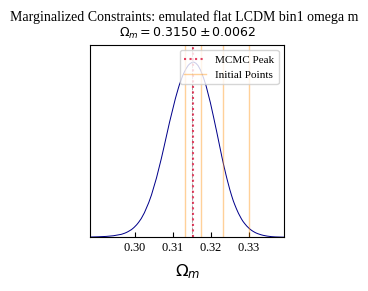

Saved trace plot to: plots/MCMC_runs/traces_and_dists/emulated_flat_LCDM_bin1_omega_m_traces.png


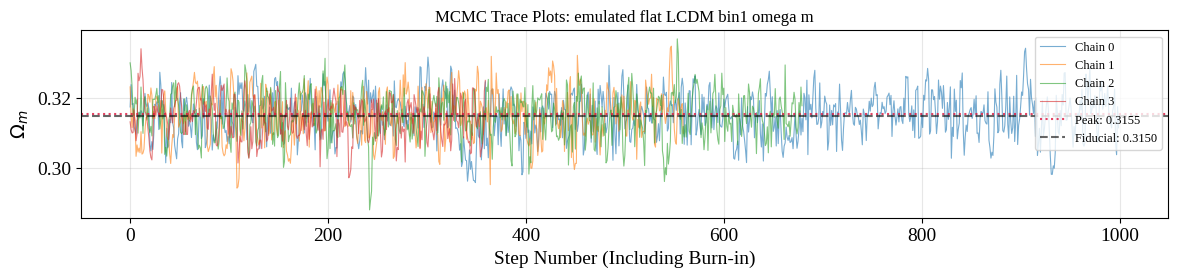

In [9]:
# plot results for emulated_flat_LCDM_bin1_omega_m_likelihood

print("Results for omega_m emulated flat LCDM bin1 MCMC:")
print("Runtime: 15 min 48 sec")
print("[mcmc] Reached maximum number of accepted steps allowed (1000). Stopping.")
print("")


# Define your environment paths
chain_folder = os.path.expanduser('~/DESIxSO/chains/emulated_flat_LCDM_bin1_omega_m_likelihood')
yaml_file_path = '/global/homes/l/lialubit/DESIxSO/yaml/emulated_flat_LCDM_bin1_omega_m_likelihood.yaml'
params_list = ['Omega_m']

# Call the clean-name variant of the function
plot_cobaya_mcmc_results(
    chain_dir=chain_folder,
    yaml_path=yaml_file_path,
    sampled_params=params_list,
    num_chains=4,
    burn_in_fraction=0.2,
    output_dir='plots/MCMC_runs/traces_and_dists'
)

Results for 1-bin emulated lensing ratios flat_LCDM MCMC sampling over omega_m and A_s:
[mcmc] The run has converged!
[mcmc] Sampling complete after 1920 accepted steps.
Runtime: 23 min 52 sec

There's a slight preference for lower A_s.
-- I wonder if this is a high-l non-linearity effect, or if it has to do with the ratios not being perfectly agnostic.
It's a pretty similar graph to the one we got pre-reordering with n_ell = 3000 instead of 5000.
In the previous graph, there was still a preference for lower A_s, but there was a peak around the fiducial value, probably because all the chains started there.

Reading fiducial values from: /global/homes/l/lialubit/DESIxSO/yaml/emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood.yaml
Derived fiducial Omega_m = Omega_c + Omega_b = 0.3150
Processing 4 chains from: /global/homes/l/lialubit/DESIxSO/chains/emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood
Saved triangle plot to: plots/MCMC_runs/traces_and_dists/emulated_le

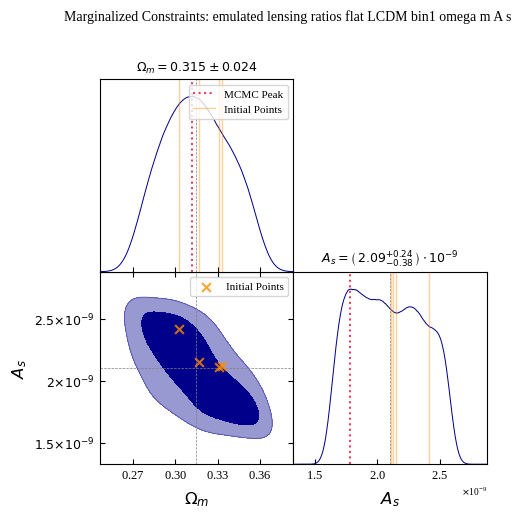

Saved trace plot to: plots/MCMC_runs/traces_and_dists/emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_traces.png


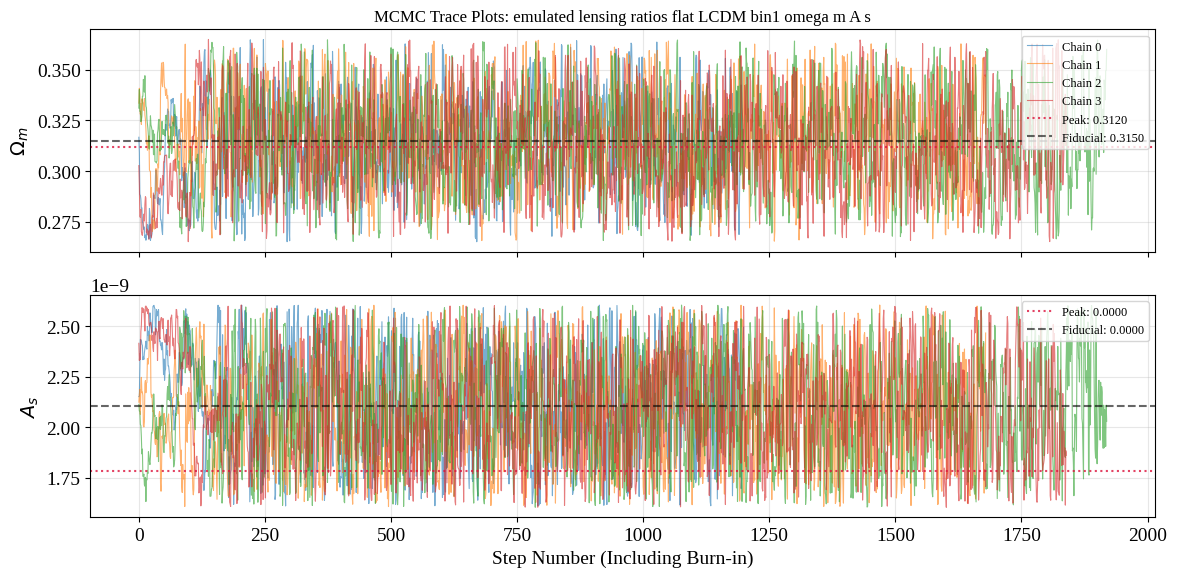

In [11]:
# plot results for emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood
print("Results for 1-bin emulated lensing ratios flat_LCDM MCMC sampling over omega_m and A_s:")
print("[mcmc] The run has converged!")
print("[mcmc] Sampling complete after 1920 accepted steps.")
print("Runtime: 23 min 52 sec")
print("")
print("There's a slight preference for lower A_s.")
print("-- I wonder if this is a high-l non-linearity effect, or if it has to do with the ratios not being perfectly agnostic.")
print("It's a pretty similar graph to the one we got pre-reordering with n_ell = 3000 instead of 5000.")
print("In the previous graph, there was still a preference for lower A_s, but there was a peak around the fiducial value, probably because all the chains started there.")
print("")

# Define your environment paths
chain_dir = os.path.expanduser('~/DESIxSO/chains/emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood')
yaml_file_path = '/global/homes/l/lialubit/DESIxSO/yaml/emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood.yaml'
params_list = ['Omega_m', 'A_s']

# Call the clean-name variant of the function
plot_cobaya_mcmc_results(
    chain_dir=chain_dir,
    yaml_path=yaml_file_path,
    sampled_params=params_list,
    num_chains=4,
    burn_in_fraction=0.2,
    output_dir='plots/MCMC_runs/traces_and_dists'
)

Results for low-l (1500) 1-bin emulated lensing ratios flat_LCDM MCMC sampling over omega_m and A_s:
Runtime: 16 min 34 sec.
[mcmc] The run has converged!
[mcmc] Sampling complete after 2800 accepted steps.
There still seems a slight low-A_s bias. I also wonder if those peaks are just the starting points of the chains.

Reading fiducial values from: /global/homes/l/lialubit/DESIxSO/yaml/emulated_low_l_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood.yaml
Derived fiducial Omega_m = Omega_c + Omega_b = 0.3150
Processing 4 chains from: /global/homes/l/lialubit/DESIxSO/chains/emulated_low_l_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood
Saved triangle plot to: plots/MCMC_runs/traces_and_dists/emulated_low_l_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_triangle_plot.pdf


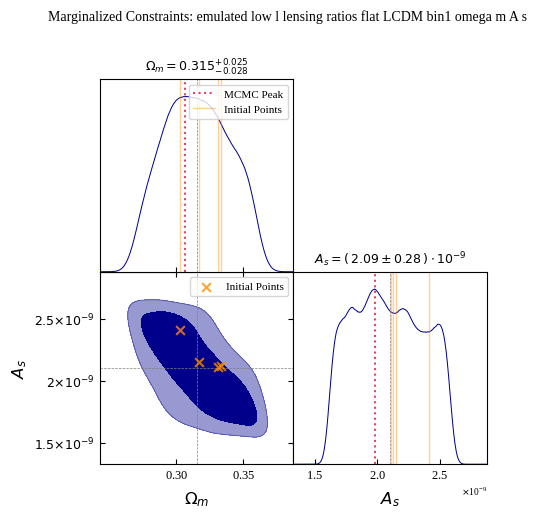

Saved trace plot to: plots/MCMC_runs/traces_and_dists/emulated_low_l_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_traces.png


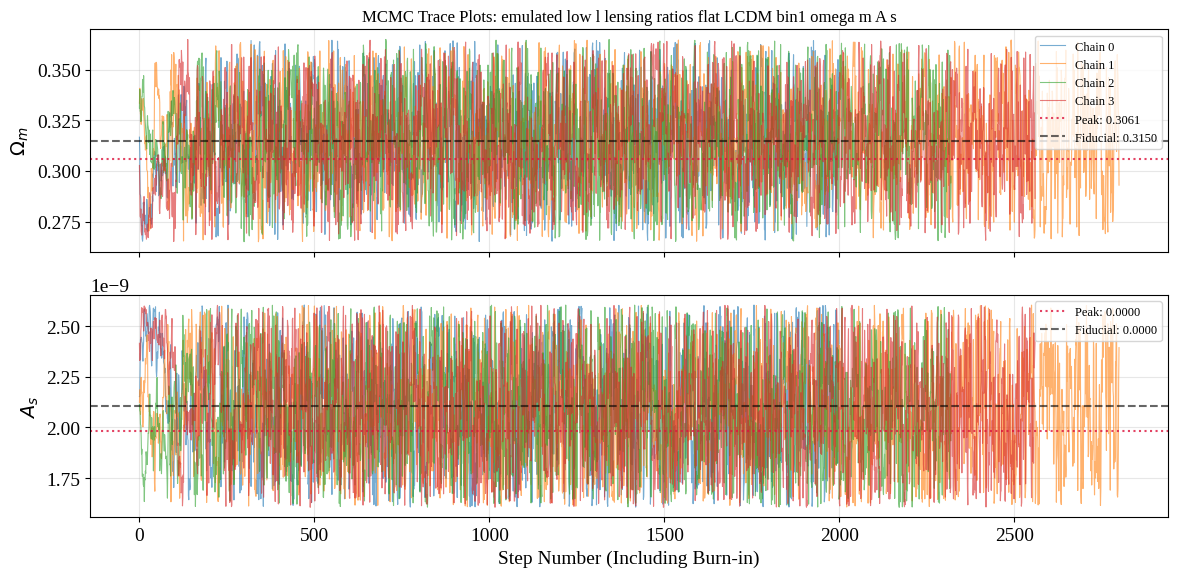

In [12]:
# plot results for emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood
print("Results for low-l (1500) 1-bin emulated lensing ratios flat_LCDM MCMC sampling over omega_m and A_s:")
print("Runtime: 16 min 34 sec.")
print("[mcmc] The run has converged!")
print("[mcmc] Sampling complete after 2800 accepted steps.")
print("There still seems a slight low-A_s bias. I also wonder if those peaks are just the starting points of the chains.")
print("")

# Define your environment paths
chain_dir = os.path.expanduser('~/DESIxSO/chains/emulated_low_l_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood')
yaml_file_path = '/global/homes/l/lialubit/DESIxSO/yaml/emulated_low_l_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood.yaml'
params_list = ['Omega_m', 'A_s']

# Call the clean-name variant of the function
plot_cobaya_mcmc_results(
    chain_dir=chain_dir,
    yaml_path=yaml_file_path,
    sampled_params=params_list,
    num_chains=4,
    burn_in_fraction=0.2,
    output_dir='plots/MCMC_runs/traces_and_dists'
)

Results for 1-bin emulated MCMC sampling over omega_m and A_s:
Runtime: ~ 40 min
[mcmc] Learn + convergence test @ 2240 samples accepted.
[mcmc]  - Acceptance rate: 0.437
[mcmc]  - Convergence of means: R-1 = 0.015206 after 1792 accepted steps
[mcmc] Progress @ 2026-06-11 12:36:59 : 5008 steps taken, and 2241 accepted.
^Csrun: interrupt (one more within 1 sec to abort

Reading fiducial values from: /global/homes/l/lialubit/DESIxSO/yaml/emulated_flat_LCDM_bin1_omega_m_A_s_likelihood.yaml
Derived fiducial Omega_m = Omega_c + Omega_b = 0.3150
Processing 4 chains from: /global/homes/l/lialubit/DESIxSO/chains/emulated_flat_LCDM_bin1_omega_m_A_s_likelihood
Saved triangle plot to: plots/MCMC_runs/traces_and_dists/emulated_flat_LCDM_bin1_omega_m_A_s_triangle_plot.pdf


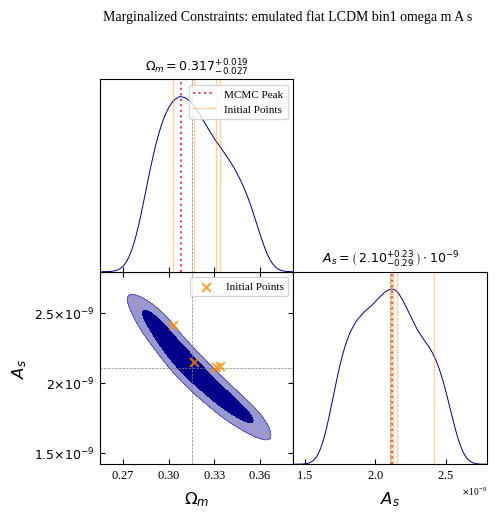

Saved trace plot to: plots/MCMC_runs/traces_and_dists/emulated_flat_LCDM_bin1_omega_m_A_s_traces.png


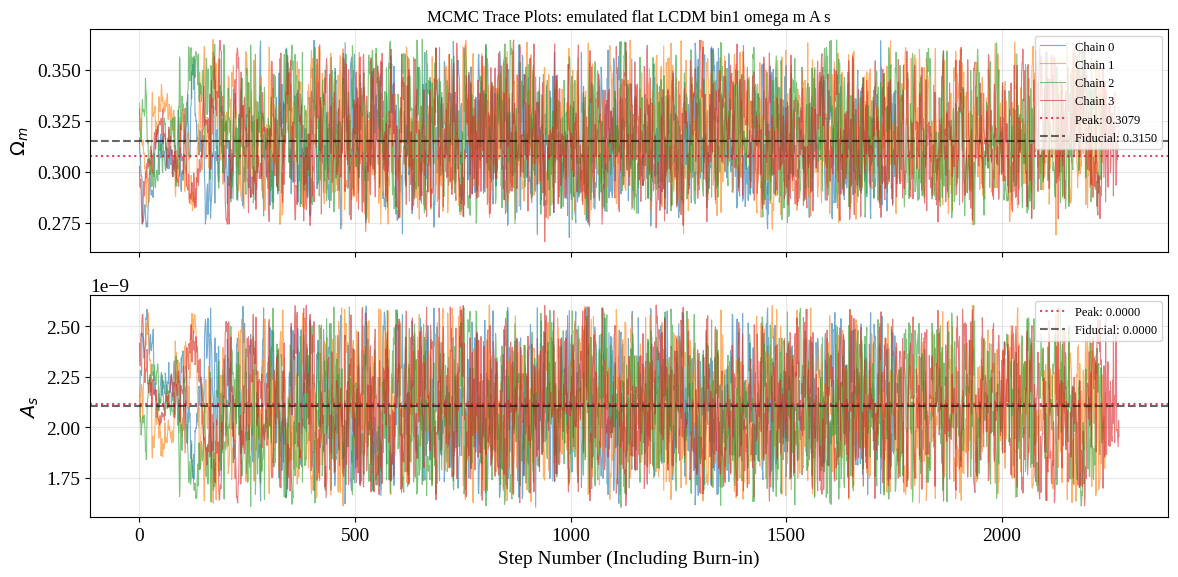

In [13]:
# plot results for emulated_flat_LCDM_bin1_omega_m_A_s_likelihood
print("Results for 1-bin emulated MCMC sampling over omega_m and A_s:")
print("Runtime: ~ 40 min")
print("[mcmc] Learn + convergence test @ 2240 samples accepted.")
print("[mcmc]  - Acceptance rate: 0.437")
print("[mcmc]  - Convergence of means: R-1 = 0.015206 after 1792 accepted steps")
print("[mcmc] Progress @ 2026-06-11 12:36:59 : 5008 steps taken, and 2241 accepted.")
print("^Csrun: interrupt (one more within 1 sec to abort")
print("")

chain_dir = os.path.expanduser('~/DESIxSO/chains/emulated_flat_LCDM_bin1_omega_m_A_s_likelihood')
yaml_file_path = '/global/homes/l/lialubit/DESIxSO/yaml/emulated_flat_LCDM_bin1_omega_m_A_s_likelihood.yaml'
params_list = ['Omega_m', 'A_s']

# Call the clean-name variant of the function
plot_cobaya_mcmc_results(
    chain_dir=chain_dir,
    yaml_path=yaml_file_path,
    sampled_params=params_list,
    num_chains=4,
    burn_in_fraction=0.2,
    output_dir='plots/MCMC_runs/traces_and_dists',
    complete=False
)

### waw0 CDM

Results for source bin1 all lens bins emulated lensing ratios waw0 MCMC sampling over omega_m, wa, and w0:
Runtime: 5 hours 35 min.
Reading fiducial values from: /global/homes/l/lialubit/DESIxSO/yaml/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_likelihood.yaml
Derived fiducial Omega_m = Omega_c + Omega_b = 0.3158
Processing 4 chains from: /global/homes/l/lialubit/DESIxSO/chains/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_likelihood
Saved triangle plot to: plots/MCMC_runs/traces_and_dists/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_triangle_plot.pdf


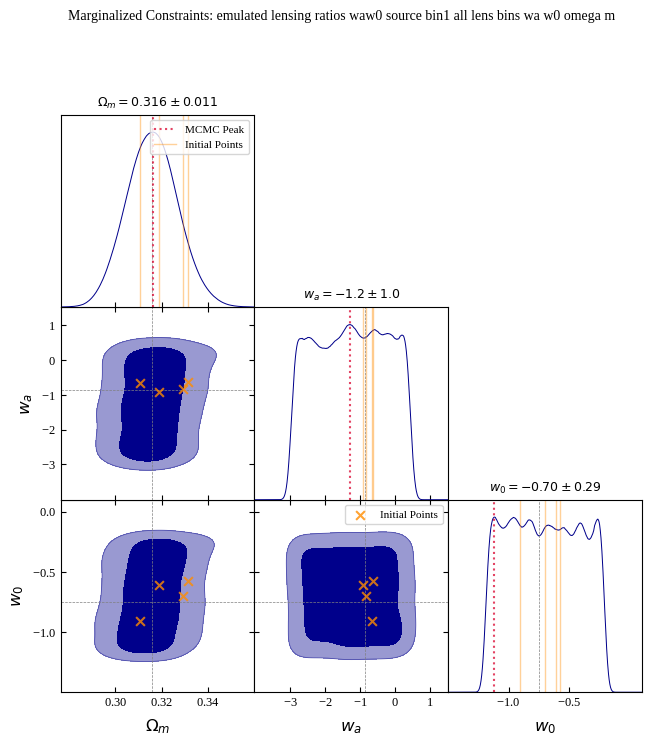

Saved trace plot to: plots/MCMC_runs/traces_and_dists/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_traces.png


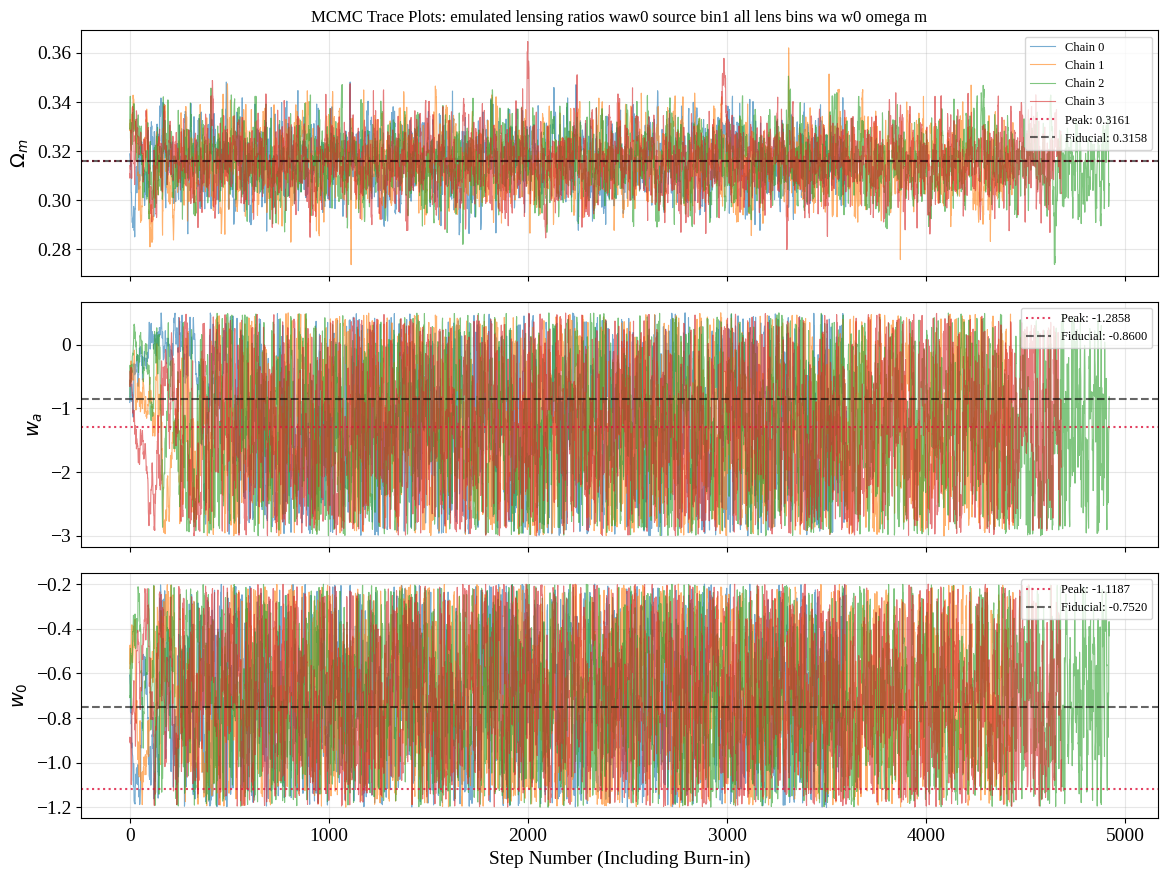

In [16]:
# plot results for emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_likelihood
print("Results for source bin1 all lens bins emulated lensing ratios waw0 MCMC sampling over omega_m, wa, and w0:")
print("Runtime: 5 hours 35 min.")

chain_folder = os.path.expanduser('~/DESIxSO/chains/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_likelihood')
yaml_file_path = '/global/homes/l/lialubit/DESIxSO/yaml/emulated_lensing_ratios_waw0_source_bin1_all_lens_bins_wa_w0_omega_m_likelihood.yaml'
params_list = ['Omega_m', 'wa', 'w0']

plot_cobaya_mcmc_results(
    chain_dir=chain_folder,
    yaml_path=yaml_file_path,
    sampled_params=params_list,
    num_chains=4,                 
    burn_in_fraction=0.2,        
    output_dir='plots/MCMC_runs/traces_and_dists'         
)

Results for all photometric bins emulated lensing ratios waw0 MCMC sampling over all params:
INCOMPLETE
Runtime: 20 hours -- cut off by time limit, not even close to convergence.

Reading fiducial values from: /global/homes/l/lialubit/DESIxSO/yaml/emulated_lensing_ratios_waw0_all_photometric_bins_full_likelihood.yaml
Derived fiducial Omega_m = Omega_c + Omega_b = 0.3158
Processing 8 chains from: /global/homes/l/lialubit/DESIxSO/chains/emulated_lensing_ratios_waw0_all_photometric_bins_likelihood_incomplete
Saved triangle plot to: plots/MCMC_runs/traces_and_dists/emulated_lensing_ratios_waw0_all_photometric_bins_incomplete_triangle_plot.pdf


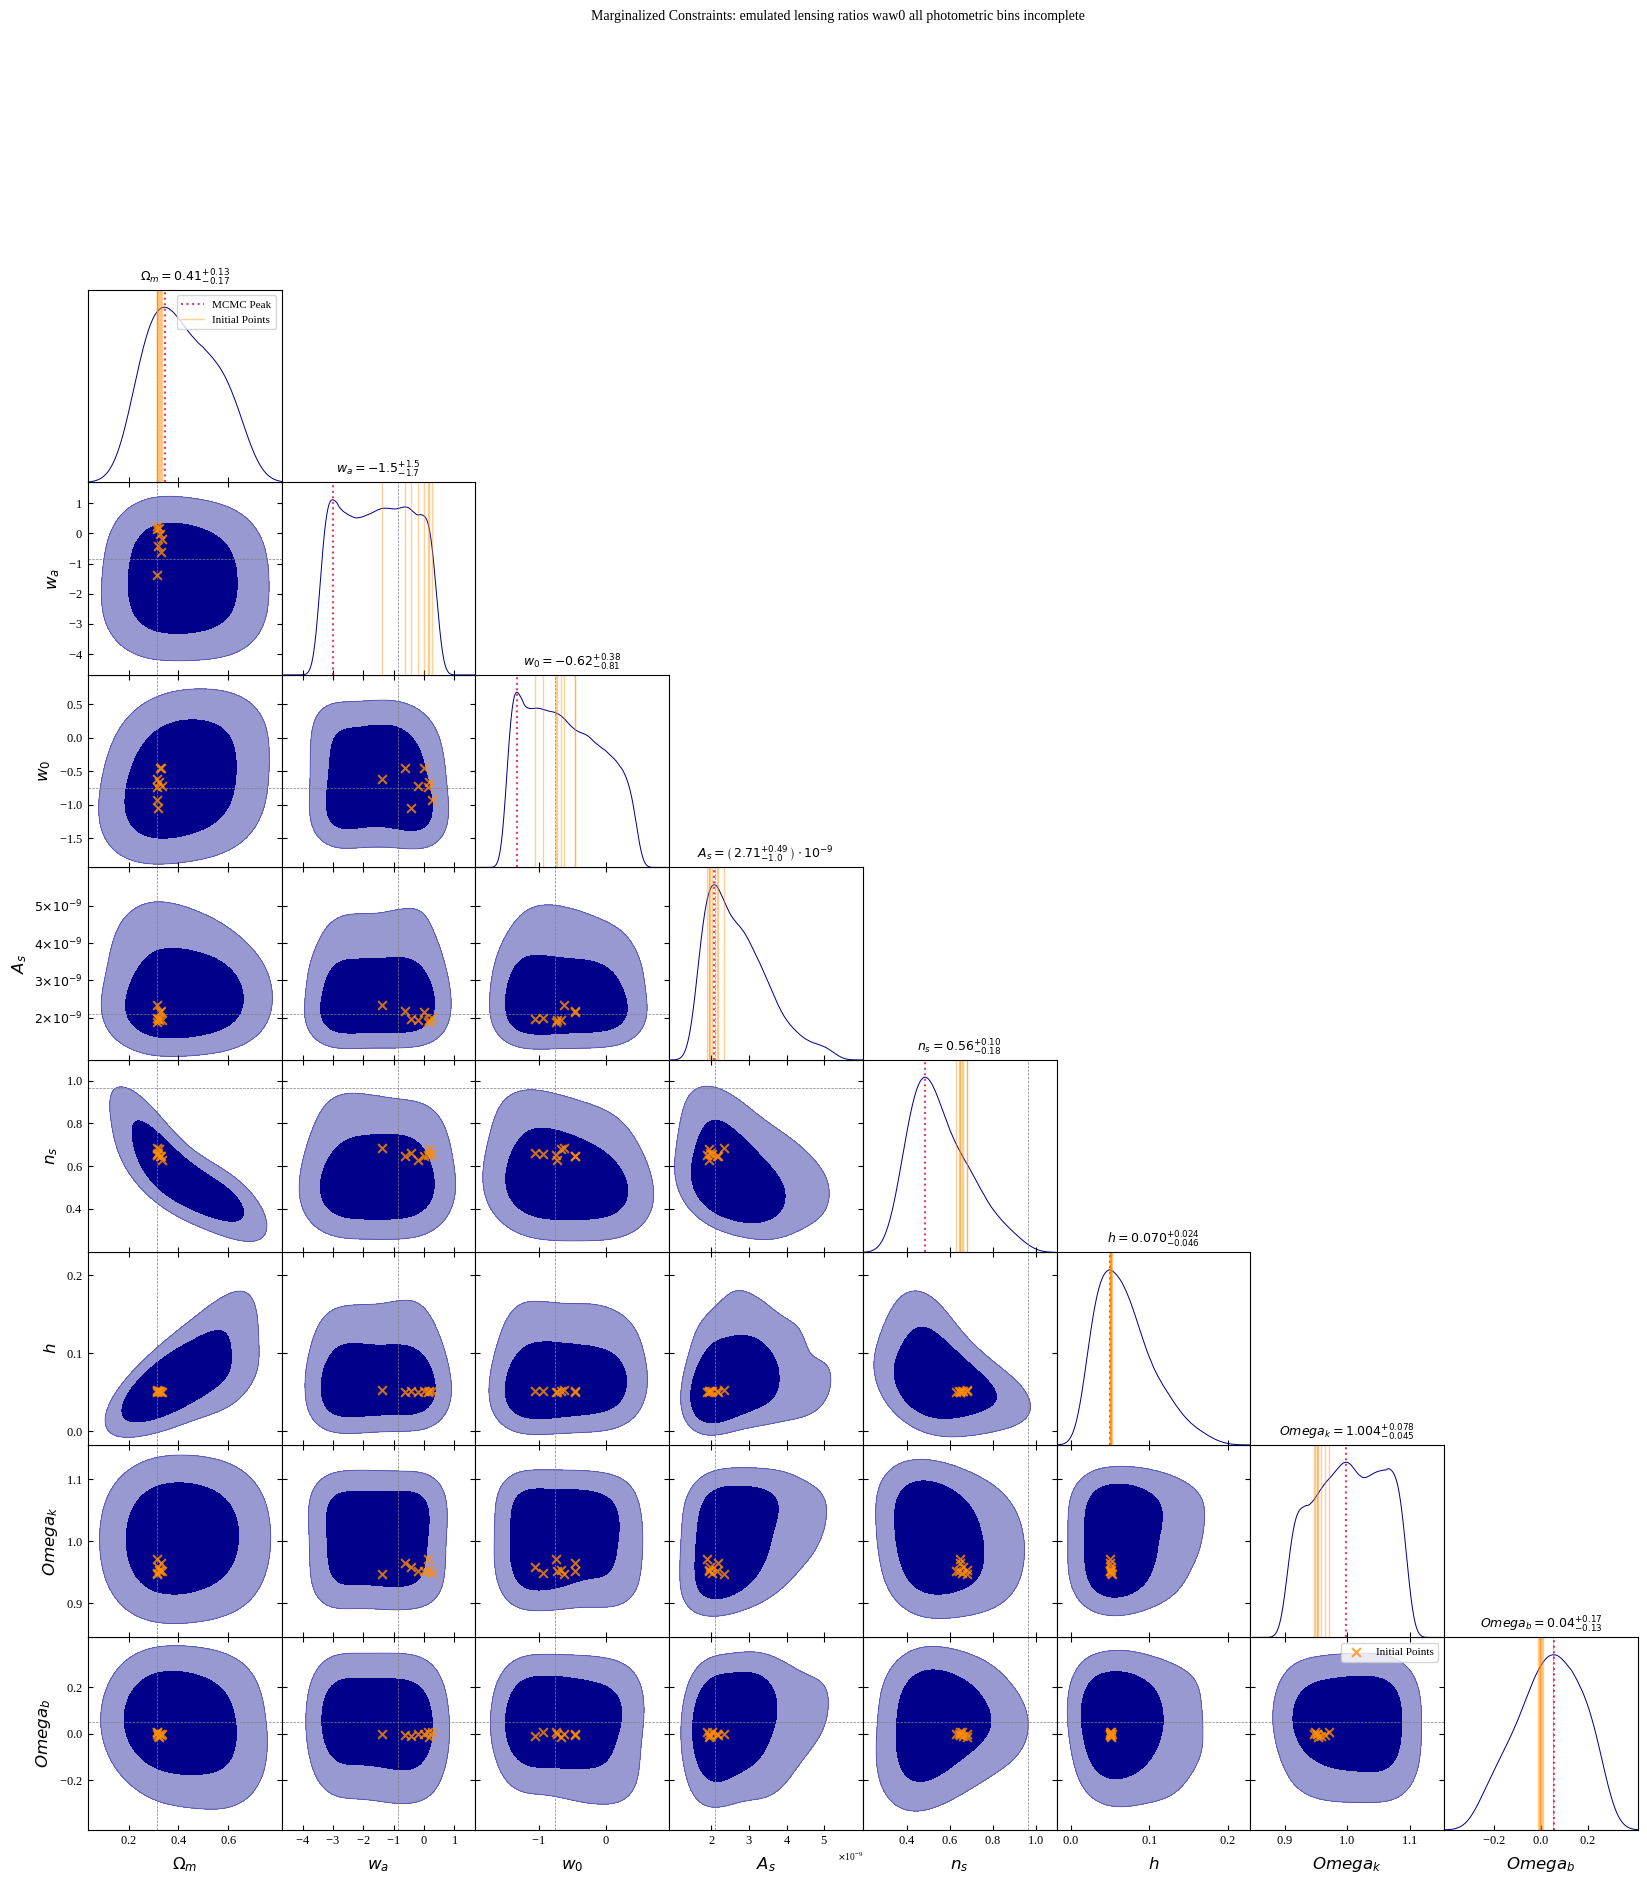

Saved trace plot to: plots/MCMC_runs/traces_and_dists/emulated_lensing_ratios_waw0_all_photometric_bins_incomplete_traces.png


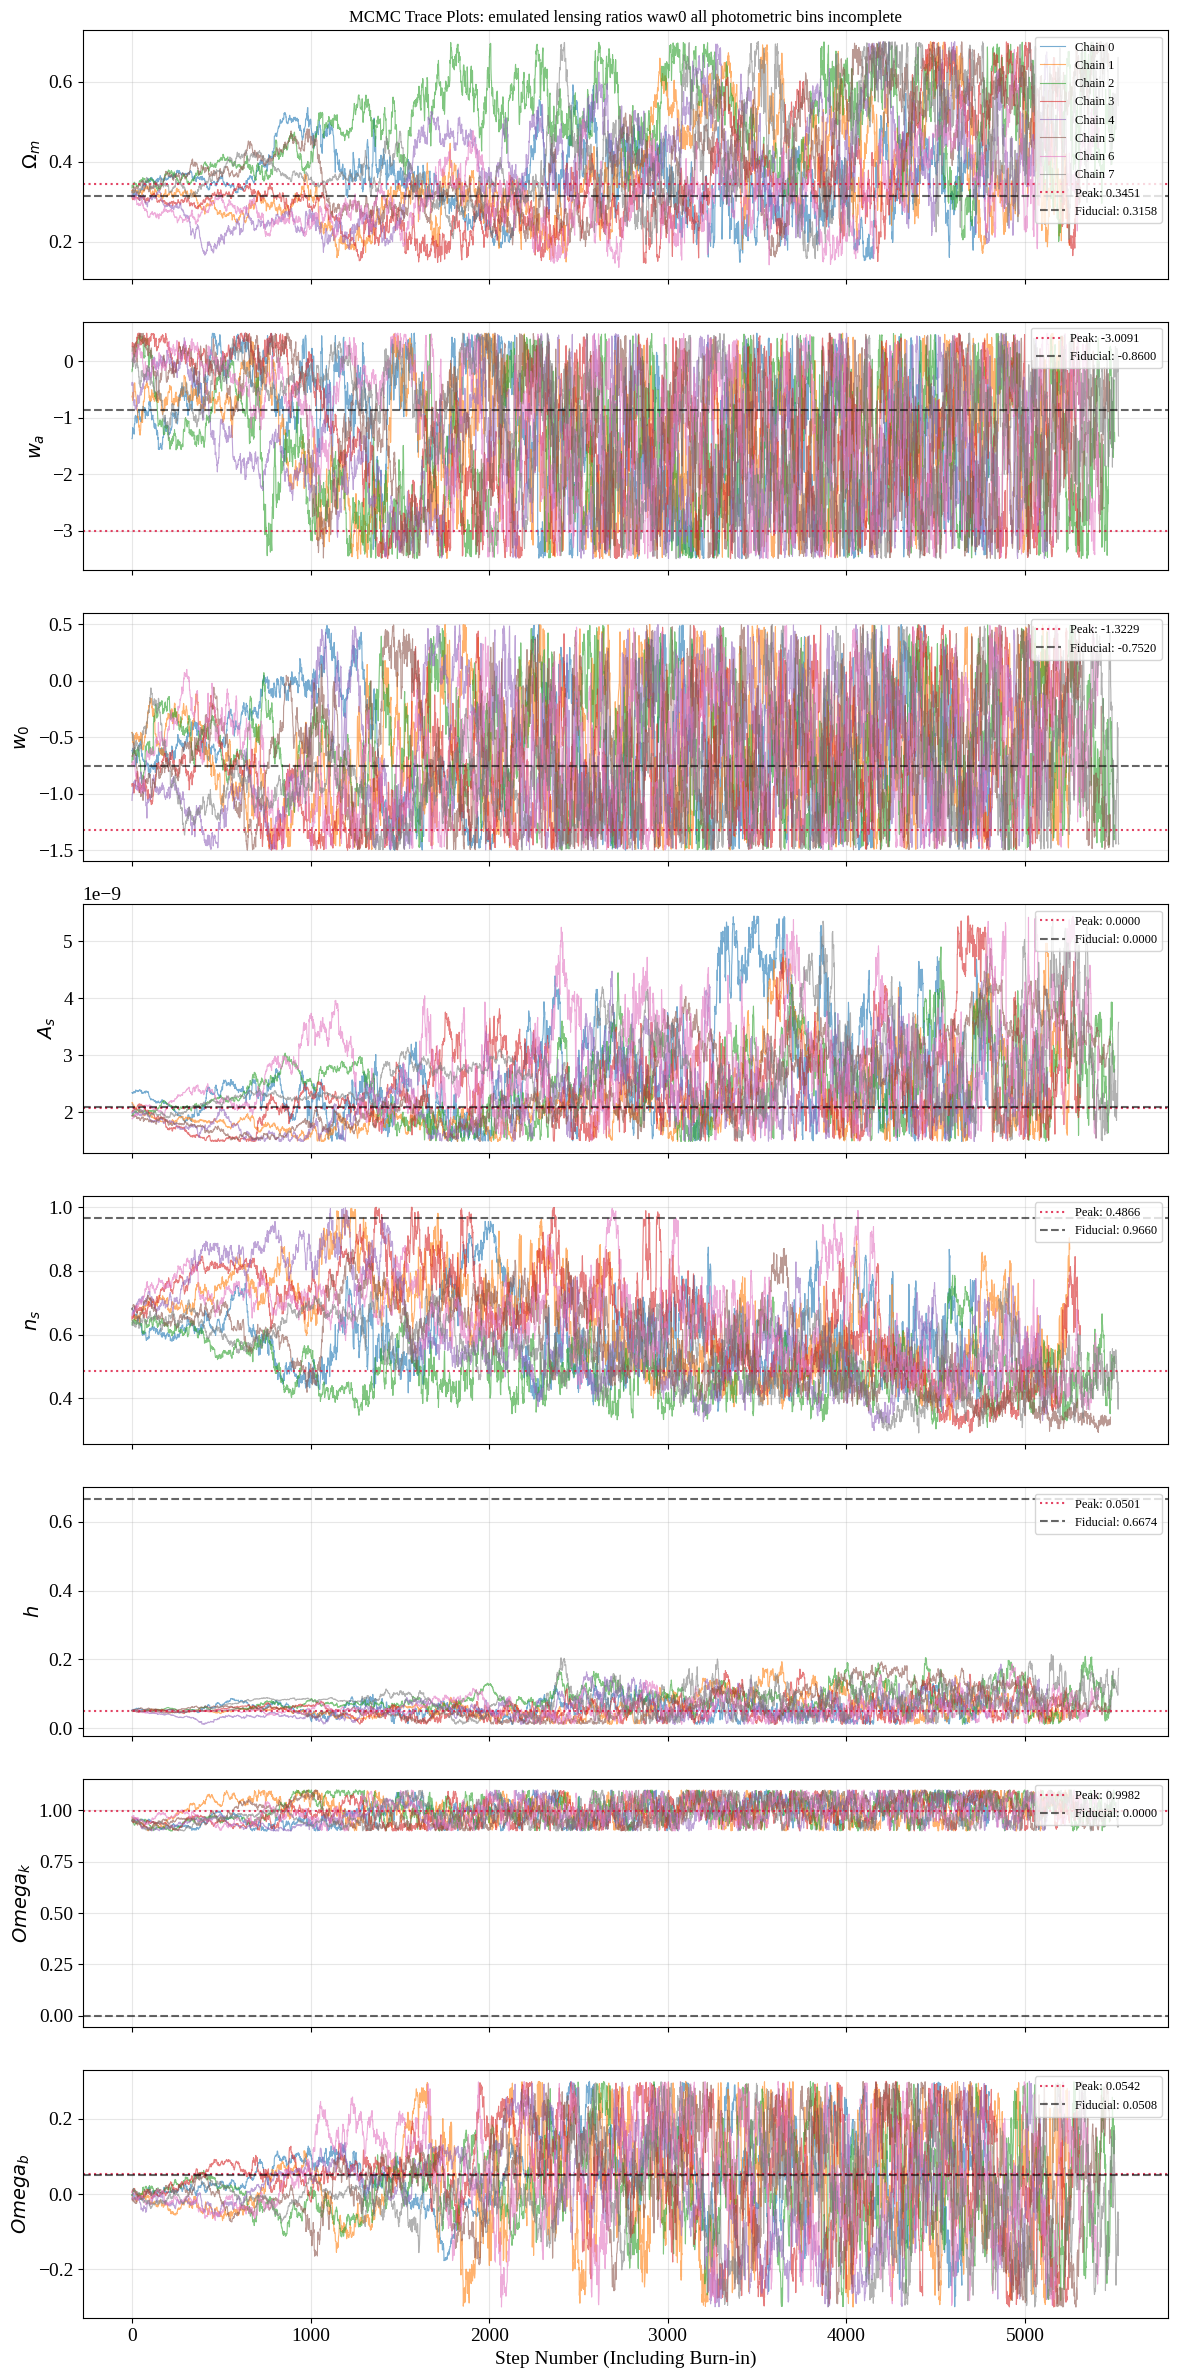

In [15]:
# plot results for emulated_lensing_ratios_waw0_all_photometric_bins_full_likelihood
print("Results for all photometric bins emulated lensing ratios waw0 MCMC sampling over all params:")
print("INCOMPLETE")
print("Runtime: 20 hours -- cut off by time limit, not even close to convergence.")
print("")

chain_folder = os.path.expanduser('~/DESIxSO/chains/emulated_lensing_ratios_waw0_all_photometric_bins_likelihood_incomplete')
yaml_file_path = '/global/homes/l/lialubit/DESIxSO/yaml/emulated_lensing_ratios_waw0_all_photometric_bins_full_likelihood.yaml'
params_list = ['Omega_m', 'wa', 'w0', 'A_s', 'n_s', 'h', 'Omega_k', 'Omega_b']

plot_cobaya_mcmc_results(
    chain_dir=chain_folder,
    yaml_path=yaml_file_path,
    sampled_params=params_list,
    num_chains=8,                  
    burn_in_fraction=0.2,          
    output_dir='plots/MCMC_runs/traces_and_dists',
    complete=False
)

Loading DESI + CMB...
Loading DESI + CMB + DESY5...
Loading DESI + CMB + Pantheon+...
Loading DESI + CMB + Union3...


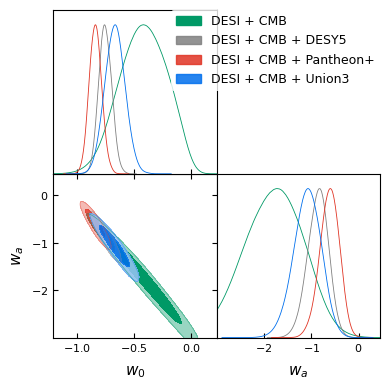

In [7]:
# plot DESI DRII contours

# The absolute NERSC path where the DESI chains live
DESI_DIR = "/global/cfs/cdirs/desi/public/papers/y3/bao-cosmo-params/cobaya/base_w_wa"

# Mapping the exact folder names from NERSC to readable legend labels
datasets = {
    "DESI + CMB": "desi-bao-all_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
    "DESI + CMB + DESY5": "desi-bao-all_desy5sn_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
    "DESI + CMB + Pantheon+": "desi-bao-all_pantheonplus_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
    "DESI + CMB + Union3": "desi-bao-all_union3_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing"
}

# Load the samples straight from CFS
samples = {}
for label, folder_name in datasets.items():
    # 'chain' is the root prefix for chain.1.txt, chain.2.txt, etc.
    chain_root = os.path.join(DESI_DIR, folder_name, "chain")
    
    print(f"Loading {label}...")
    samples[label] = loadMCSamples(chain_root, settings={'ignore_rows': 0.3})

# Initialize the plotter for a beautiful inline Jupyter notebook display
g = plots.get_subplot_plotter()

# Customize plot settings to mimic official papers
g.settings.num_plot_contours = 2  # 68% and 95% intervals
g.settings.figure_legend_frame = False

# Plot the 2D contour overlay for dark energy parameters w and wa
g.triangle_plot(
    list(samples.values()), 
    params=['w', 'wa'], 
    legend_labels=list(samples.keys()),
    filled=True
)

### Chi2 Evaluations

In [ ]:
# the following chi2 values use the pre-reordering functions and n_ell = 3000
# they should be accurate still, just a touch out-dated

[model] *WARNING* Ignored blocks/options: ['sampler', 'output']
Initializing SO_x_DESI_Likelihood...
  Loading lens shot noise from: data/DESI_shot_noise_bin1.npy
  Loading source shape noise from: data/DESI_shape_noise_bin1.npy
  Loading CMB noise from: data/SO_CMB_noise.npy
  Loaded lens data from data/DESI_lens_data_bin1.npy
  Loaded source data from: data/HSC_dist_0_3_bin1.npy
  Loading observed data vector from: cobaya_data/emulated_flat_LCDM_bin1_data_vector.npy
  Loading covariance matrix from: cobaya_data/emulated_flat_LCDM_bin1_covariance_matrix.npy
SO_x_DESI_Likelihood initialized successfully.
Starting grid scan...


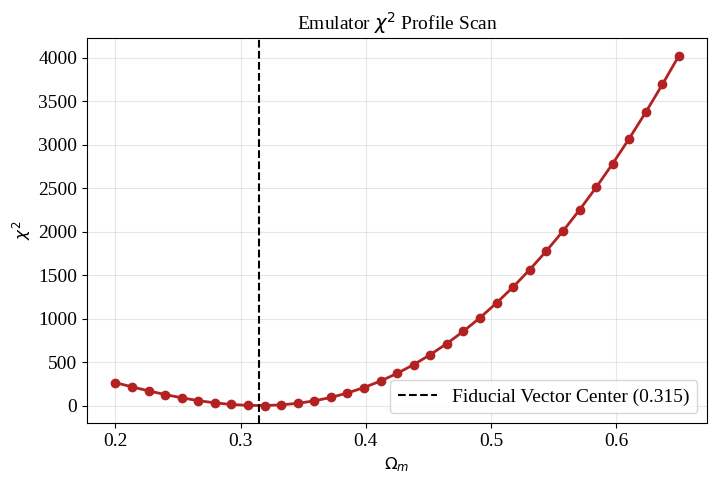

In [13]:
# get chi2 values for omega_m using emulated likelihood

info = "yaml/emulated_flat_LCDM_bin1_omega_m_likelihood.yaml"
model = get_model(info)
like_object = model.likelihood["functions_and_classes.SO_x_DESI_Likelihood_w_emulator"]

# define omega_m grid
omega_m_grid = np.linspace(0.20, 0.65, 35)
chi2_values = []

# 4. Loop through the grid and evaluate the chi2
print("Starting grid scan...")
for om in omega_m_grid:
    # pass the target parameter along with your fiducial values
    # profile_chi2 function will automatically compute Omega_c = Omega_m - Omega_b inside
    chi2 = like_object.profile_chi2(
        Omega_m=om,
        Omega_b=0.045,
        h=0.674,
        A_s=2.105e-9,
        n_s=0.96,
        w0=-1.0,
        wa=0.0,
        Omega_k=0.0
    )
    chi2_values.append(chi2)

# plot
plt.figure(figsize=(8, 5))
plt.plot(omega_m_grid, chi2_values, marker='o', color='firebrick', lw=2)
plt.axvline(0.315, color='black', linestyle='--', label='Fiducial Vector Center (0.315)')
plt.xlabel(r"$\Omega_m$", fontsize=12)
plt.ylabel(r"$\chi^2$", fontsize=12)
plt.title(r"Emulator $\chi^2$ Profile Scan", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

[model] *WARNING* Ignored blocks/options: ['sampler', 'output']
Initializing SO_x_DESI_Likelihood...
  Loading lens shot noise from: data/DESI_shot_noise_bin1.npy
  Loading source shape noise from: data/DESI_shape_noise_bin1.npy
  Loading CMB noise from: data/SO_CMB_noise.npy
  Loaded lens data from data/DESI_lens_data_bin1.npy
  Loaded source data from: data/HSC_dist_0_3_bin1.npy
  Loading observed data vector from: cobaya_data/emulated_lensing_ratios_flat_LCDM_bin1_data_vector.npy
  Loading covariance matrix from: cobaya_data/emulated_lensing_ratios_flat_LCDM_bin1_covariance_matrix.npy
SO_x_DESI_Likelihood initialized successfully.
Starting 2D grid scan...
Evaluating step 20/400...
Evaluating step 40/400...
Evaluating step 60/400...
Evaluating step 80/400...
Evaluating step 100/400...
Evaluating step 120/400...
Evaluating step 140/400...
Evaluating step 160/400...
Evaluating step 180/400...
Evaluating step 200/400...
Evaluating step 220/400...
Evaluating step 240/400...
Evaluating st

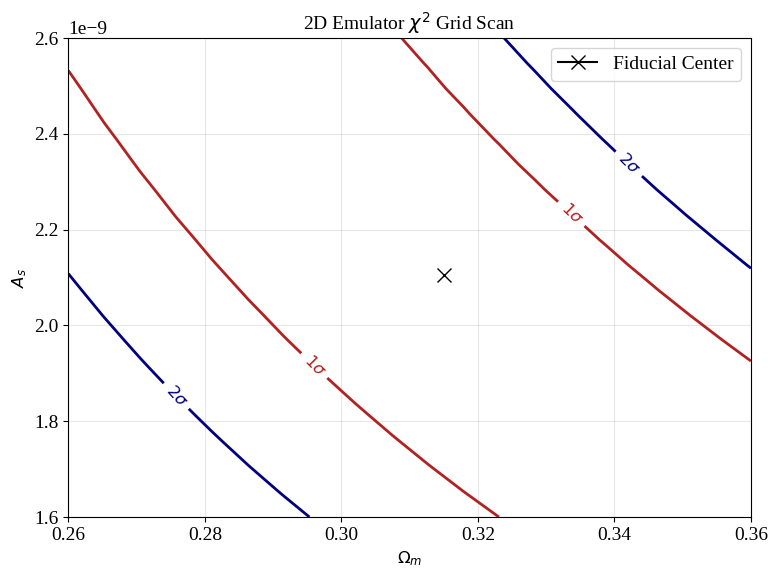

In [14]:
# plot chi2 for emulated abridge likelihood

# 1. Initialize the model and likelihood object
info = "yaml/emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood.yaml"
model = get_model(info)
like_object = model.likelihood["functions_and_classes.SO_x_DESI_Likelihood_w_emulator"]

# 2. Define grids for BOTH parameters
omega_m_grid = np.linspace(0.26, 0.36, 20)
A_s_grid = np.linspace(1.6e-9, 2.6e-9, 20)

# Create empty matrix to hold chi2 values
chi2_matrix = np.zeros((len(A_s_grid), len(omega_m_grid)))

# Create a counter
step = 0
total_steps = len(A_s_grid) * len(omega_m_grid)

print("Starting 2D grid scan...")
for i, as_val in enumerate(A_s_grid):
    for j, om in enumerate(omega_m_grid):
        step += 1
        if step % 20 == 0:  # Prints an update every 20 points
            print(f"Evaluating step {step}/{total_steps}...")
            
        chi2 = like_object.profile_chi2(
            Omega_m=om,
            Omega_b=0.045,
            h=0.674,
            A_s=as_val,
            n_s=0.96,
            w0=-1.0,
            wa=0.0,
            Omega_k=0.0
        )
        chi2_matrix[i, j] = chi2

# 4. Process the Chi2 surface for plotting
min_chi2 = np.min(chi2_matrix)
delta_chi2 = chi2_matrix - min_chi2  # Delta Chi2 relative to best-fit

# 5. Plot the 2D confidence contours
plt.figure(figsize=(8, 6))

# Standard 2D Gaussian confidence intervals: 1-sigma (Delta Chi2 = 2.30), 2-sigma (Delta Chi2 = 6.18)
contour = plt.contour(omega_m_grid, A_s_grid, delta_chi2, levels=[2.30, 6.18], colors=['firebrick', 'navy'], linewidths=2)
plt.clabel(contour, inline=True, fmt={2.30: r'$1\sigma$', 6.18: r'$2\sigma$'}, fontsize=12)

# Mark the fiducial center
plt.plot(0.315, 2.105e-9, marker='x', color='black', markersize=10, label='Fiducial Center')

plt.xlabel(r"$\Omega_m$", fontsize=12)
plt.ylabel(r"$A_s$", fontsize=12)
plt.title(r"2D Emulator $\chi^2$ Grid Scan", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Recreation of Pratt Results

In [ ]:
# reference: https://arxiv.org/pdf/1810.02212
# sigma_epsilone = 0.26
# For the purposes of these forecasts, we adopt the best-fit ΛCDM cosmological 
# model from the analysis ofTT,TE,EE+lowP+lensing+ext datasets in Ade et al. (2016).

# We do LSST + CMB-S4 since that's one of two that is graphed, and I didn't want to deal with separate populations of lens bins

# Source Bins: We assume that LSST is used to measure shapes of source galaxies,
# with a source density of 25 galaxies per sq. arcmin and redshift range from z = 1.0 to z = 1.6.
# Lens Bins:  We assume that the LSST tracer galaxy sample is divided into 10 bins 
# between z = 0.2 and z = 0.7, with number density of 100 galaxies per square degree for each bin.
# CMB Lensing: The CMB lensing map is assumed to come from a Stage 4 (CMB-S4) like experiment
# we adopt the minimum variance CMB lensing noise curve from Schaan et al.
# multiplicative shear bias from LSST can be calibrated to σ(m) = 0.001

# Prior: geometrical Planck prior, curved LCDM, sample over omega_k, omega_m, w
#  marginalize over h and Ωb as these appear in the geometrical Planck prior

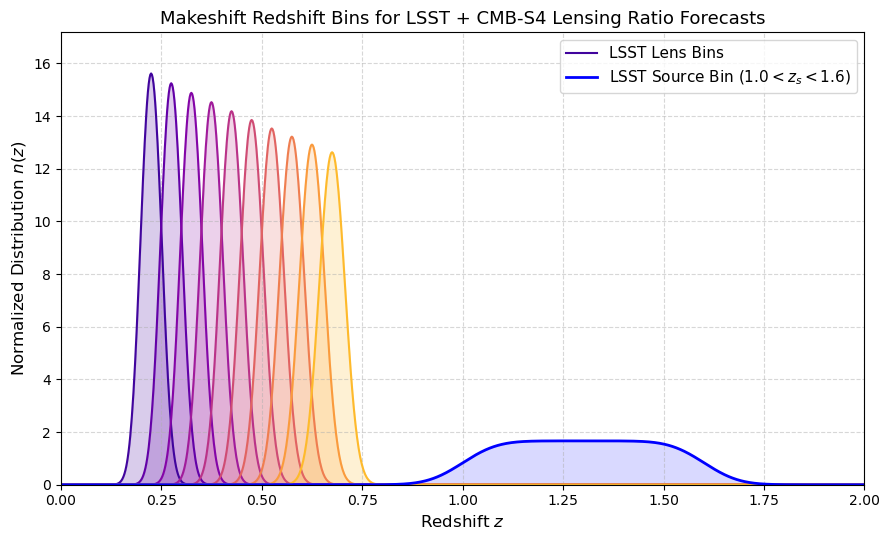

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# create lens and source bins to be used for Pratt check
# LSST + CMB-S4

# define redshift grid
z = np.linspace(0.0, 2.0, 1000)
dz = z[1] - z[0]

# build the 10 photometric lens bins (0.2 < z < 0.7) with equal number of galaxies
lens_edges = np.linspace(0.2, 0.7, 11)
lens_bins = []

# assume a redMaGiC-like photo-z scatter profile: \sigma_z = 0.0166 * (1 + z)
# "Such densities are comparable to what is currently achieved with DES redMaGiC"
# "the DES Y1 redMaGiC photo-zs have a scatter of σz = 0.0166(1 + z)"
for i in range(10):
    z_min, z_max = lens_edges[i], lens_edges[i+1]
    z_mid = (z_min + z_max) / 2.0
    
    # initialize nominal window
    top_hat = np.zeros_like(z)
    top_hat[(z >= z_min) & (z <= z_max)] = 1.0
    
    # Calculate pixel-level Gaussian smoothing representing photo-z scatter
    sigma = 0.0166 * (1 + z_mid)
    sigma_pix = sigma / dz
    
    # Convolve to get the realistic underlying true n(z) distribution
    nz_lens = gaussian_filter1d(top_hat, sigma_pix)
    
    # Normalize the distribution
    if np.sum(nz_lens) > 0:
        nz_lens /= np.sum(nz_lens) * dz
    lens_bins.append(nz_lens)

# build the single source bin (1.0 < z < 1.6)
source_min, source_max = 1.0, 1.6
source_mid = (source_min + source_max) / 2.0

top_hat_source = np.zeros_like(z)
top_hat_source[(z >= source_min) & (z <= source_max)] = 1.0

# LSST expected source sample photo-z scatter seems to be ~ \sigma_z = 0.03 * (1 + z)
# https://arxiv.org/pdf/2510.07370
sigma_src = 0.03 * (1 + source_mid)
sigma_src_pix = sigma_src / dz
nz_source = gaussian_filter1d(top_hat_source, sigma_src_pix)
nz_source /= np.sum(nz_source) * dz

# make into arrays
Pratt_lens_data = np.column_stack([z] + lens_bins)
Pratt_source_data = np.column_stack((z, nz_source))

# plot
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.plasma(np.linspace(0.1, 0.85, 10))
z_plot = Pratt_lens_data[:, 0]

for i in range(10):
    nz_plot = Pratt_lens_data[:, i + 1]
    lbl = 'LSST Lens Bins' if i == 0 else ""
    ax.plot(z_plot, nz_plot, color=colors[i], lw=1.5, label=lbl)
    ax.fill_between(z_plot, nz_plot, color=colors[i], alpha=0.2)

ax.plot(Pratt_source_data[:, 0], Pratt_source_data[:, 1], color='blue', lw=2, label='LSST Source Bin ($1.0 < z_s < 1.6$)')
ax.fill_between(Pratt_source_data[:, 0], Pratt_source_data[:, 1], color='blue', alpha=0.15)

ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel('Normalized Distribution $n(z)$', fontsize=12)
ax.set_title('Makeshift Redshift Bins for LSST + CMB-S4 Lensing Ratio Forecasts', fontsize=13)
ax.set_xlim(0.0, 2.0)
ax.set_ylim(0.0, max(np.max(lens_bins) * 1.1, np.max(nz_source) * 1.1))
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('lsst_cmbs4_bins.png', dpi=300)
plt.show()

In [ ]:
# noise

Pratt_shot_noise = 
Pratt_shape_noise = 
Pratt_CMB_noise = 

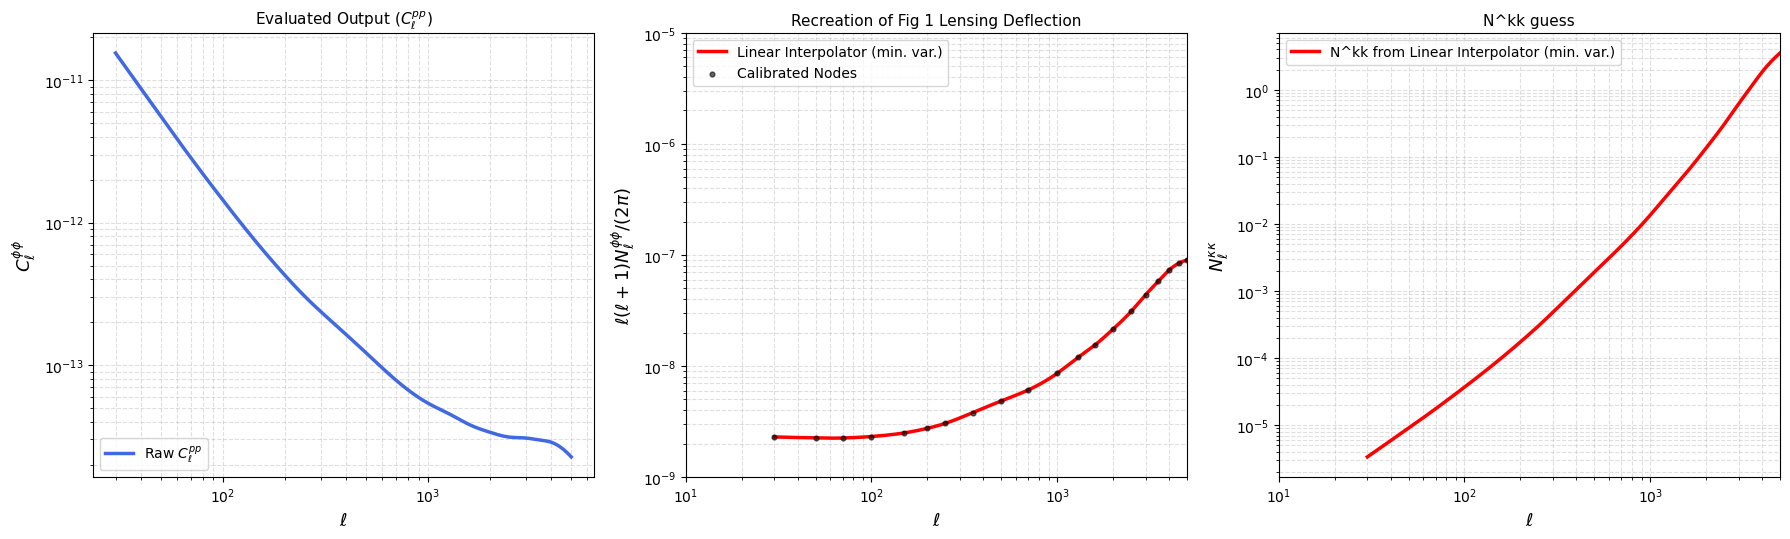

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline, interp1d

# 1. High-precision nodes capturing the flat start, the mid-range bump, and the steep end
ell_nodes = np.array([
    30, 50, 70, 100, 150, 200, 250, 350, 500, 700, 1000, 
    1300, 1600, 2000, 2500, 3000, 3500, 4000, 4500, 5000
])
scaled_nodes = np.array([
    2.30e-9,  # l=30 (start)
    2.25e-9,  # Shallow dip
    2.25e-9,  
    2.32e-9,  # l=100
    2.50e-9,  # Gradual rise starts
    2.75e-9,  # l=200
    3.05e-9,  # Entering the shoulder/bump region
    3.80e-9,  
    4.85e-9,  # Slows down slightly right before l=500
    6.10e-9,  # l=700
    8.60e-9,  # l=1000 (Passes just under the 10^-8 line)
    1.20e-8,  
    1.55e-8,  
    2.15e-8,  # Undergoes the steep upward turn past l=2000
    3.10e-8,  
    4.40e-8,  # l=3000
    5.80e-8,  
    7.30e-8,  
    8.40e-8,  
    9.00e-8   # Terminates under the 10^-7 line at l=5000
])

# 2. Generate a dense baseline path
# This populates intermediate steps to ensure raw linear interpolation behaves smoothly in logspace
cs_helper = CubicSpline(np.log10(ell_nodes), np.log10(scaled_nodes))
ell_base = np.logspace(np.log10(30), np.log10(5000), 500)
scaled_base = 10**cs_helper(np.log10(ell_base))

# De-scale the baseline values back to raw Cl^pp parameters:
# Cl^pp = (scaled_value * 2pi) / (l*(l+1))
cl_pp_base = scaled_base * (2 * np.pi) / (ell_base * (ell_base + 1))

# 3. Instantiate the pure LINEAR interpolator for raw Cl^pp coordinates
cl_pp_linear_interpolator = interp1d(ell_base, cl_pp_base, kind='linear', fill_value='extrapolate')

# 4. Define the target evaluation array (representing the input array)
ell_array = np.logspace(np.log10(30), np.log10(5000), 1000)

# 5. Apply the linear interpolator to the evaluation array
cl_pp_evaluated = cl_pp_linear_interpolator(ell_array)

# Re-scale back for plotting coordinates: l(l+1)C_l^pp / 2pi
scaled_evaluated = ell_array * (ell_array + 1) * cl_pp_evaluated / (2 * np.pi)

n_kk_evaluated = (np.pi / 2) * ell_array * (ell_array + 1) * scaled_evaluated

# =====================================================================
# 6. Plotting Execution (Rendered via Logarithmic Scale Geometry)
# =====================================================================
# Expanded subplot grid to 1 row, 3 columns to cleanly fit the new curve
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))

# Left Panel: Pure Evaluated Raw Cl^pp
ax1.plot(ell_array, cl_pp_evaluated, color='royalblue', lw=2.5, label=r'Raw $C_\ell^{pp}$')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'$\ell$', fontsize=13)
ax1.set_ylabel(r'$C_\ell^{\phi\phi}$', fontsize=13)
ax1.set_title(r'Evaluated Output ($C_\ell^{pp}$)', fontsize=11)
ax1.grid(True, which='both', linestyle='--', alpha=0.4)
ax1.legend(loc='lower left')

# Middle Panel: Exact Mirror of Figure 1 Coordinates from arXiv:1607.01761
ax2.plot(ell_array, scaled_evaluated, color='red', lw=2.5, label='Linear Interpolator (min. var.)')
ax2.scatter(ell_nodes, scaled_nodes, color='black', s=12, zorder=3, alpha=0.6, label='Calibrated Nodes')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(10, 5000)
ax2.set_ylim(1e-9, 1e-5)
ax2.set_xlabel(r'$\ell$', fontsize=13)
ax2.set_ylabel(r'$\ell(\ell + 1) N_\ell^{\phi\phi} / (2\pi)$', fontsize=13)
ax2.set_title('Recreation of Fig 1 Lensing Deflection', fontsize=11)
ax2.grid(True, which='both', linestyle='--', alpha=0.4)
ax2.legend(loc='upper left')

# Right Panel: N^kk_l
ax3.plot(ell_array, n_kk_evaluated, color='red', lw=2.5, label='N^kk from Linear Interpolator (min. var.)')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlim(10, 5000)
ax3.set_xlabel(r'$\ell$', fontsize=13)
ax3.set_ylabel(r'$N_\ell^{\kappa\kappa}$', fontsize=13)
ax3.set_title('N^kk guess', fontsize=11)
ax3.grid(True, which='both', linestyle='--', alpha=0.4)
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# how do I get from this to N^kk_l?
# what is the shot and shape noise?
# what are the priors?

In [ ]:
# calculate and save fiducial data vector and covariance matrix for Pratt LSST + CMB-S4

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for Pratt LSST + CMB-S4 reconstruction")

# cosmology params
omega_b_h2 = 0.02230 +- 0.00014
omega_c_h2 = 0.1188 +- 0.0010
ln_10_10_A_s = 3.064 +- 0.023
n_s = 0.9667 +- 0.0040
h = 0.6774 +- 0.0046
omega_m = 0.3089 +- 0.0062

# I'll use the main value of all of these and ignore the error bars
fiducial_cosmology = ccl.Cosmology(
    Omega_c=XXXX,
    Omega_b=XXXX,
    h=XXXX,
    A_s=XXXX,
    n_s=XXXX,
    w0=XXXX,
    wa=XXXX,
    Omega_k=XXXX,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.44 # this is taken from the paper they reference -- not sure if its the value they use
n_ell = 3000 # they cut off under 30 also
binsize = 50 # might increase this to speed up analysis if it takes too long
magnification_bias_lenses = None # not given...
desired_spectra = ['GL', 'CG']

# build covariance and spectra dictionary
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        fiducial_cosmology,
        Pratt_lens_data,
        Pratt_source_data,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=Pratt_shot_noise,
        shape_noise_source=Pratt_shape_noise,
        cmb_noise_phi=Pratt_CMB_noise, 
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra,
        linear_emulator=lin_emu,
        boost_emulator=boost_emu
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map.pairs:
    unbinned_cls = fiducial_spectra_dict[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# Save to files
data_vector_filename = 'cobaya_data/Pratt_LSST_CMB_S4_data_vector.npy'
covariance_filename = 'cobaya_data/Pratt_LSST_CMB_S4_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

print(f"Fiducial data vector saved to: {data_vector_filename}")
print(f"Covariance matrix saved to: {covariance_filename}")

#plot_covariance_matrix(cov_obj, fiducial_spectra_dict, f_map, binsize=50, desired_spectra=['CG', 'GL'])
#plot_correlation_matrix(cov_obj, fiducial_spectra_dict, f_map, binsize=50, desired_spectra=['CG', 'GL'])

In [ ]:
# chi2 analysis -- quick comparison w/Pratt

info = "yaml/Pratt_LSST_CMB_S4_likelihood.yaml"
model = get_model(info)
like_object = model.likelihood["functions_and_classes.SO_x_DESI_Likelihood_w_emulator"]

# 2. Define grids for BOTH parameters
Omega_m_grid = np.linspace()
Omega_k_grid = np.linspace()
w_grid = np.linspace()

# Create empty matrix to hold chi2 values
chi2_matrix = np.zeros((len(Omega_m_grid), len(Omega_k_grid), len(w_grid)))

# create a counter
step = 0
total_steps = len(Omega_m_grid) * len(Omega_k_grid) * len(w_grid)

print("Starting 3D grid scan...")
for i, om in enumerate(Omega_m_grid):
    for j, ok in enumerate(Omega_k_grid):
        for k, w in enumerate(w_grid): 
            step += 1
            if step % 20 == 0:  # Prints an update every 20 points
                print(f"Evaluating step {step}/{total_steps}...")
                
            chi2 = like_object.profile_chi2(
                Omega_m=om,
                Omega_b=XXXX,
                h=XXXX,
                A_s=XXXX,
                n_s=XXXX,
                w0=XXXX,
                wa=XXXXX,
                Omega_k=ok
            )
            chi2_matrix[i, j, k] = chi2

# process the chi2 surface for plotting
min_chi2 = np.min(chi2_matrix)
delta_chi2 = chi2_matrix - min_chi2  # Delta Chi2 relative to best-fit

#### MODIFY
# 5. Plot the 2D confidence contours
plt.figure(figsize=(8, 6))

# Standard 2D Gaussian confidence intervals: 1-sigma (Delta Chi2 = 2.30), 2-sigma (Delta Chi2 = 6.18)
contour = plt.contour(omega_m_grid, A_s_grid, delta_chi2, levels=[2.30, 6.18], colors=['firebrick', 'navy'], linewidths=2)
plt.clabel(contour, inline=True, fmt={2.30: r'$1\sigma$', 6.18: r'$2\sigma$'}, fontsize=12)

# Mark the fiducial center
plt.plot(0.315, 2.105e-9, marker='x', color='black', markersize=10, label='Fiducial Center')

plt.xlabel(r"$\Omega_m$", fontsize=12)
plt.ylabel(r"$A_s$", fontsize=12)
plt.title(r"2D Emulator $\chi^2$ Grid Scan", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()